<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/UCI_Nursery_DataSet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d heitornunes/nursery

# Unziping the downloaded file
!unzip nursery.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/heitornunes/nursery
License(s): other
  0% 0.00/40.6k [00:00<?, ?B/s]
100% 40.6k/40.6k [00:00<00:00, 116MB/s]
Archive:  nursery.zip
  inflating: nursery.csv             


In [4]:
df = pd.read_csv('nursery.csv')
df.head(11)

,parents,has_nurs,form,children,housing,finance,social,health,final evaluation
0,usual,proper,complete,1,convenient,convenient,nonprob,recommended,recommend
1,usual,proper,complete,1,convenient,convenient,nonprob,priority,priority
2,usual,proper,complete,1,convenient,convenient,nonprob,not_recom,not_recom
3,usual,proper,complete,1,convenient,convenient,slightly_prob,recommended,recommend
4,usual,proper,complete,1,convenient,convenient,slightly_prob,priority,priority
5,usual,proper,complete,1,convenient,convenient,slightly_prob,not_recom,not_recom
6,usual,proper,complete,1,convenient,convenient,problematic,recommended,priority
7,usual,proper,complete,1,convenient,convenient,problematic,priority,priority
8,usual,proper,complete,1,convenient,convenient,problematic,not_recom,not_recom
9,usual,proper,complete,1,convenient,inconv,nonprob,recommended,very_recom


In [5]:
df.tail(11)

,parents,has_nurs,form,children,housing,finance,social,health,final evaluation
12949,great_pret,very_crit,foster,more,critical,convenient,problematic,priority,spec_prior
12950,great_pret,very_crit,foster,more,critical,convenient,problematic,not_recom,not_recom
12951,great_pret,very_crit,foster,more,critical,inconv,nonprob,recommended,spec_prior
12952,great_pret,very_crit,foster,more,critical,inconv,nonprob,priority,spec_prior
12953,great_pret,very_crit,foster,more,critical,inconv,nonprob,not_recom,not_recom
12954,great_pret,very_crit,foster,more,critical,inconv,slightly_prob,recommended,spec_prior
12955,great_pret,very_crit,foster,more,critical,inconv,slightly_prob,priority,spec_prior
12956,great_pret,very_crit,foster,more,critical,inconv,slightly_prob,not_recom,not_recom
12957,great_pret,very_crit,foster,more,critical,inconv,problematic,recommended,spec_prior
12958,great_pret,very_crit,foster,more,critical,inconv,problematic,priority,spec_prior


In [6]:
df.shape

(12960, 9)

In [7]:
df.columns

Index(['parents', 'has_nurs', 'form', 'children', 'housing', 'finance',
       'social', 'health', 'final evaluation'],
      dtype='object')

In [8]:
df.dtypes

,0
parents,object
has_nurs,object
form,object
children,object
housing,object
finance,object
social,object
health,object
final evaluation,object


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12960 entries, 0 to 12959
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   parents           12960 non-null  object
 1   has_nurs          12960 non-null  object
 2   form              12960 non-null  object
 3   children          12960 non-null  object
 4   housing           12960 non-null  object
 5   finance           12960 non-null  object
 6   social            12960 non-null  object
 7   health            12960 non-null  object
 8   final evaluation  12960 non-null  object
dtypes: object(9)
memory usage: 911.4+ KB


In [10]:
df.describe(include = 'all')

,parents,has_nurs,form,children,housing,finance,social,health,final evaluation
count,12960,12960,12960,12960,12960,12960,12960,12960,12960
unique,3,5,4,4,3,2,3,3,5
top,usual,proper,complete,1,convenient,convenient,nonprob,recommended,not_recom
freq,4320,2592,3240,3240,4320,6480,4320,4320,4320


In [11]:
df.isnull().sum()

,0
parents,0
has_nurs,0
form,0
children,0
housing,0
finance,0
social,0
health,0
final evaluation,0


In [12]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

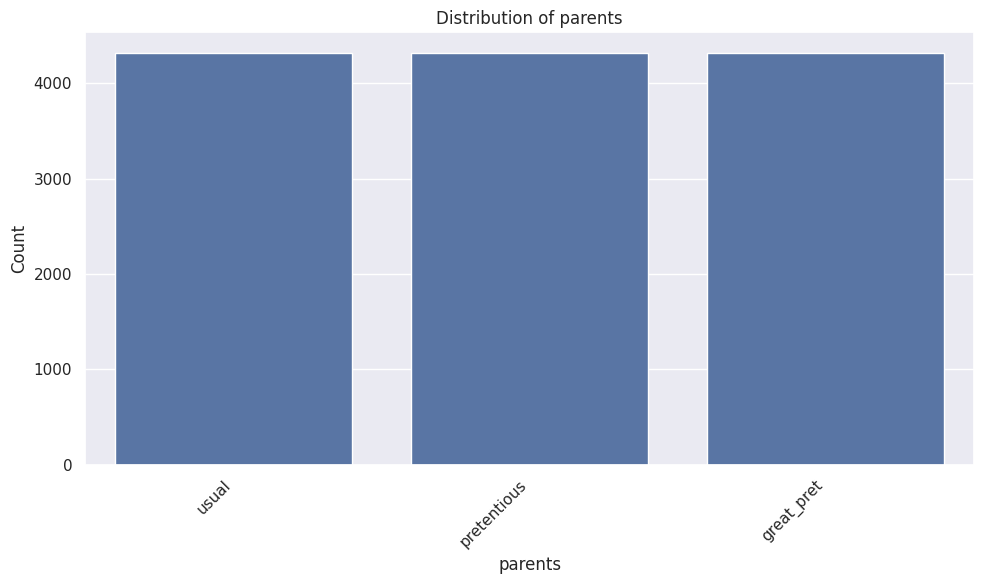

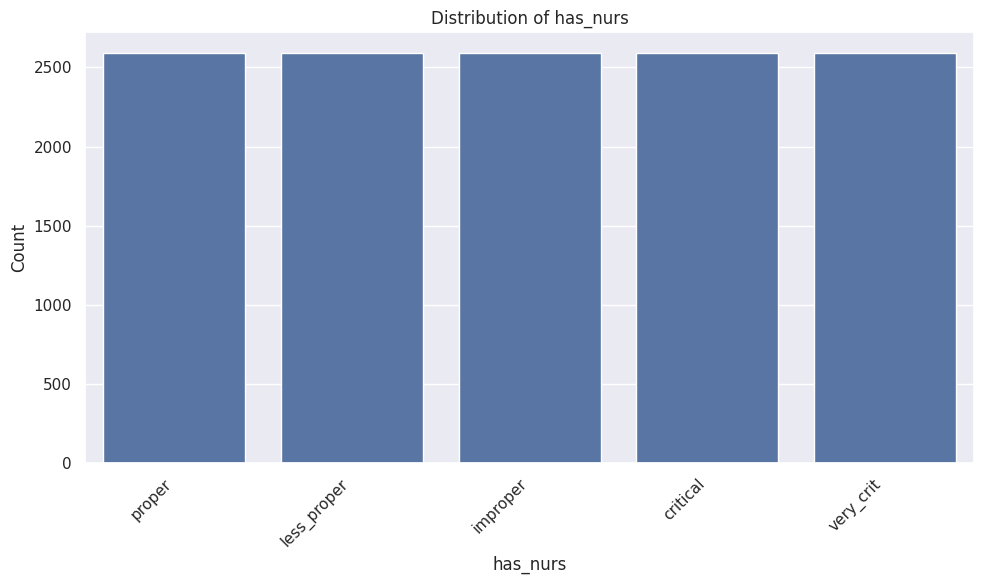

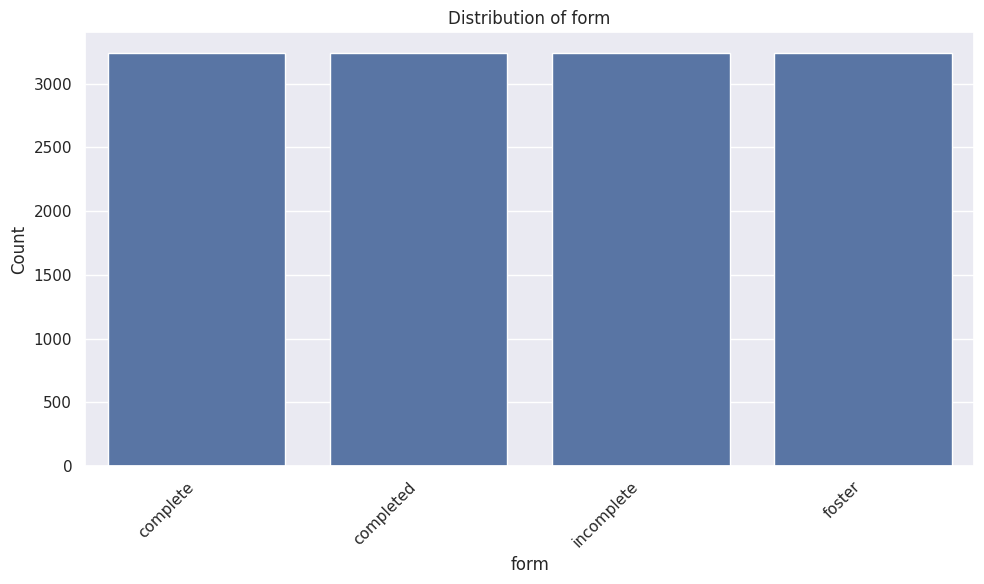

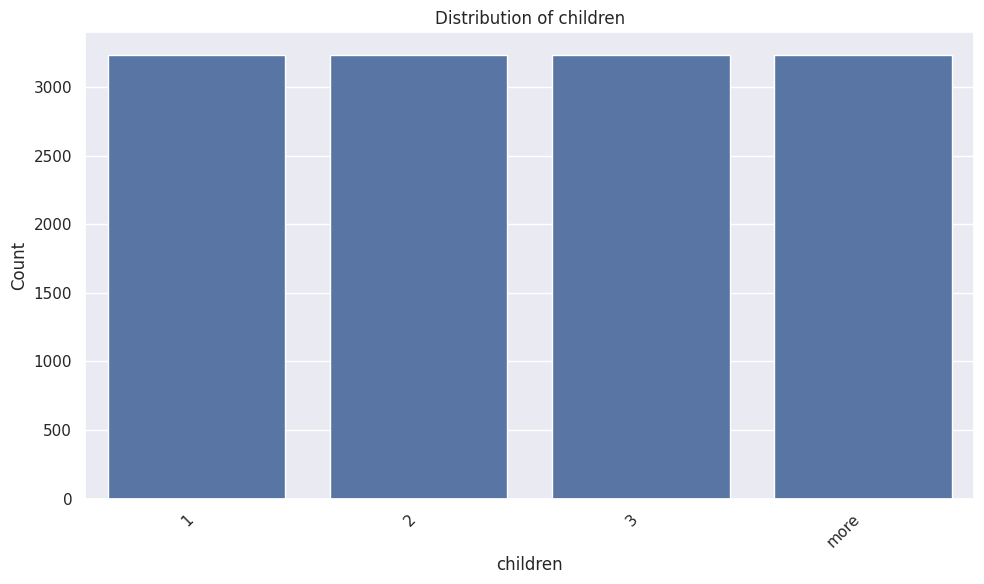

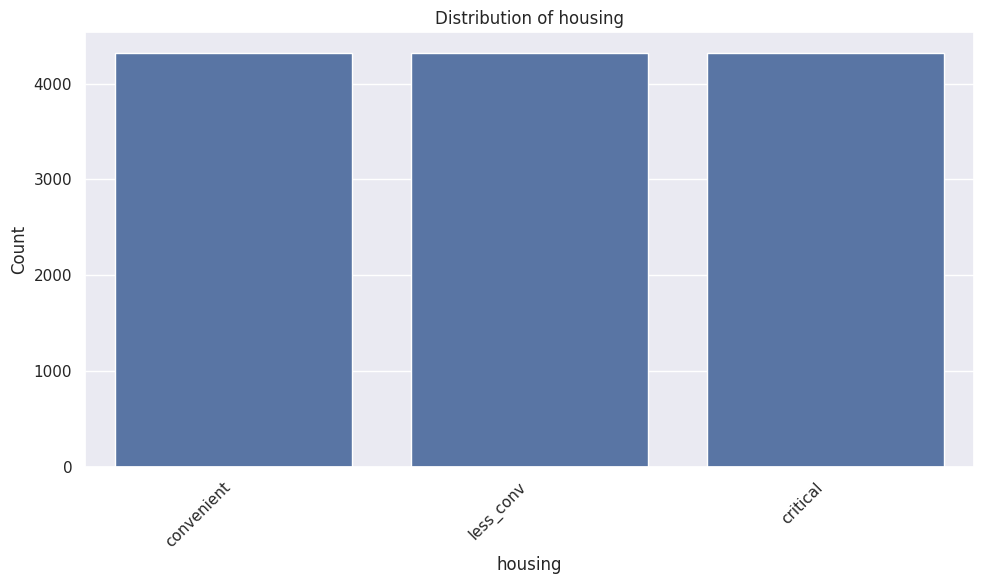

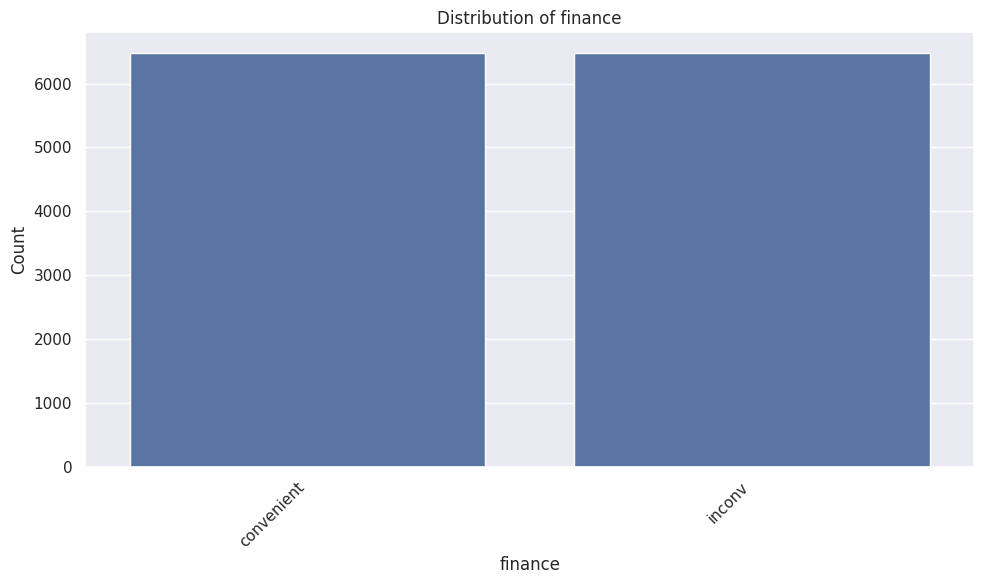

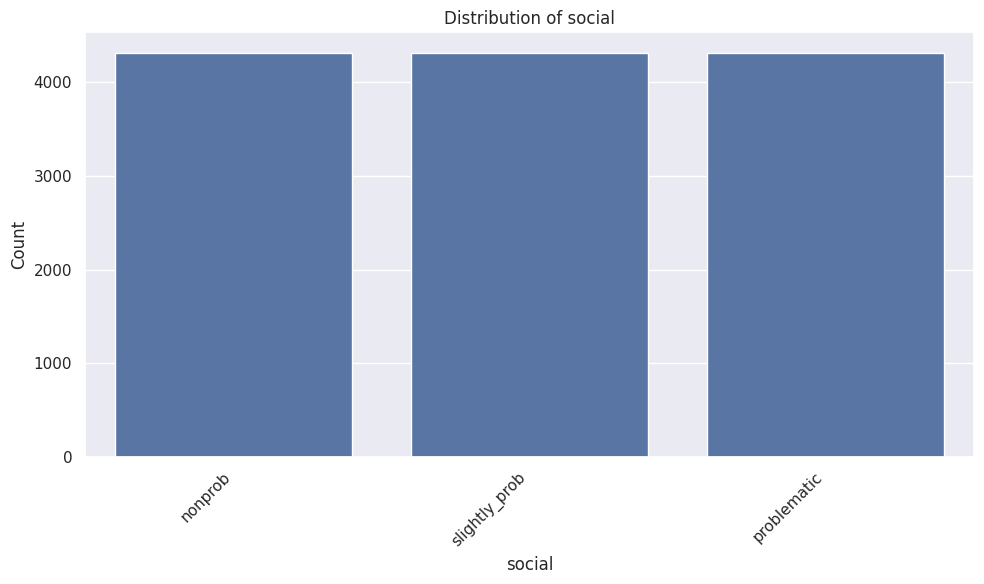

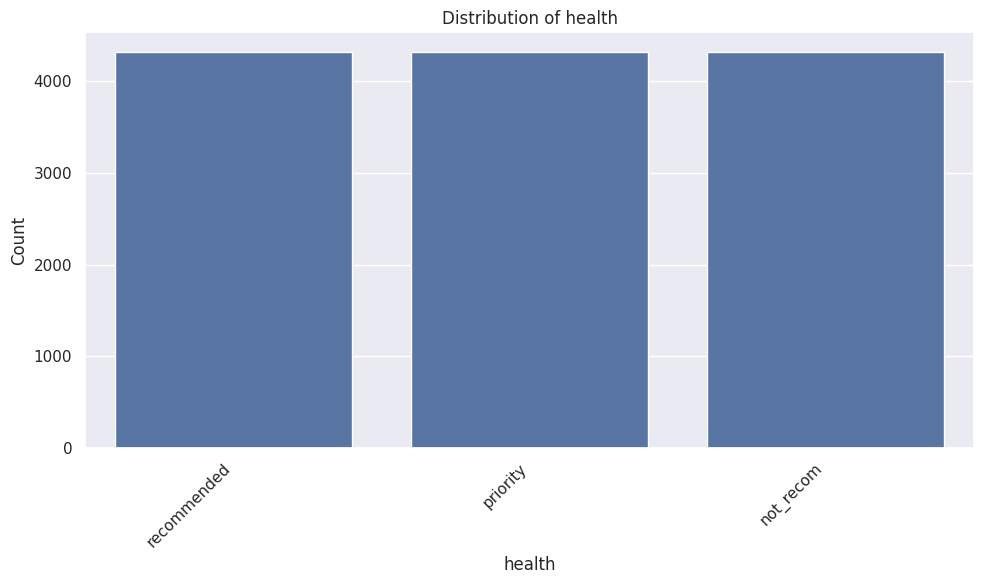

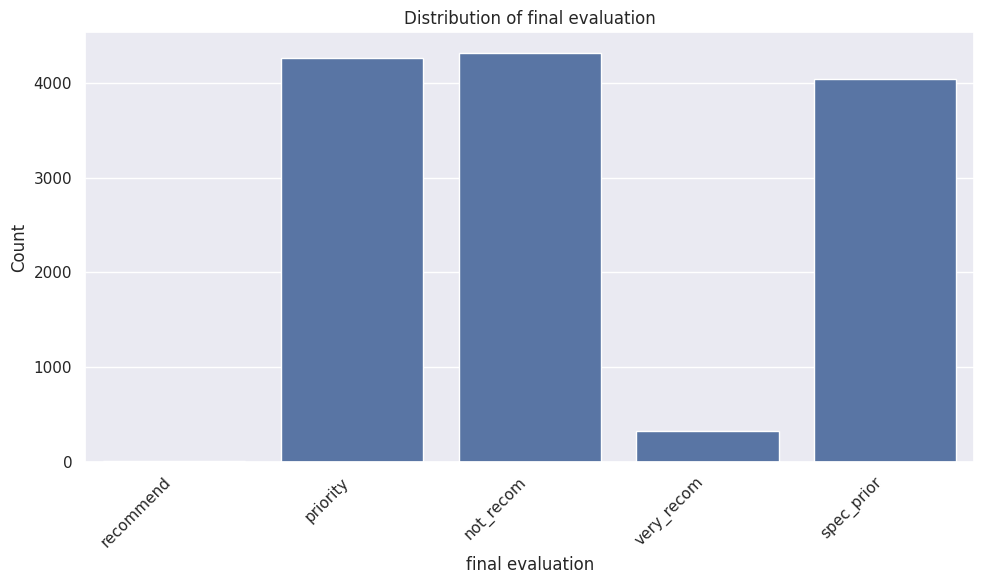

Value counts for parents:
parents
usual          4320
pretentious    4320
great_pret     4320
Name: count, dtype: int64

Value counts for has_nurs:
has_nurs
proper         2592
less_proper    2592
improper       2592
critical       2592
very_crit      2592
Name: count, dtype: int64

Value counts for form:
form
complete      3240
completed     3240
incomplete    3240
foster        3240
Name: count, dtype: int64

Value counts for children:
children
1       3240
2       3240
3       3240
more    3240
Name: count, dtype: int64

Value counts for housing:
housing
convenient    4320
less_conv     4320
critical      4320
Name: count, dtype: int64

Value counts for finance:
finance
convenient    6480
inconv        6480
Name: count, dtype: int64

Value counts for social:
social
nonprob          4320
slightly_prob    4320
problematic      4320
Name: count, dtype: int64

Value counts for health:
health
recommended    4320
priority       4320
not_recom      4320
Name: count, dtype: int64

Value cou

In [13]:
# Get a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Get a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

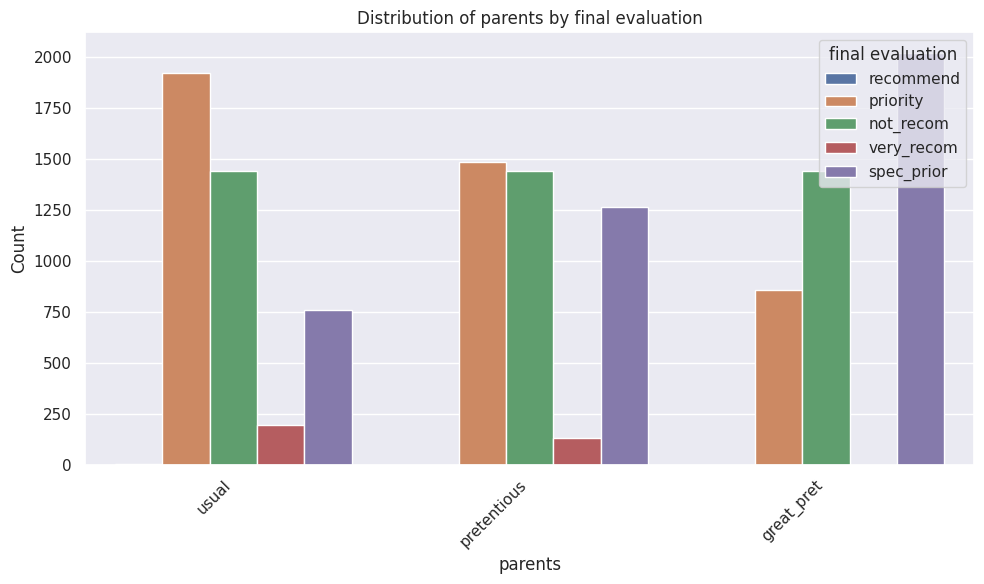

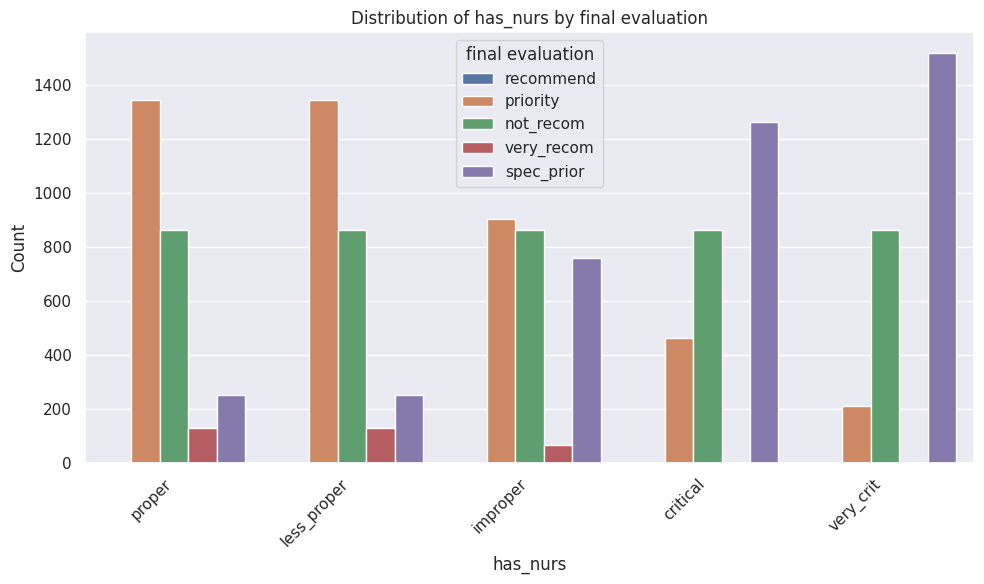

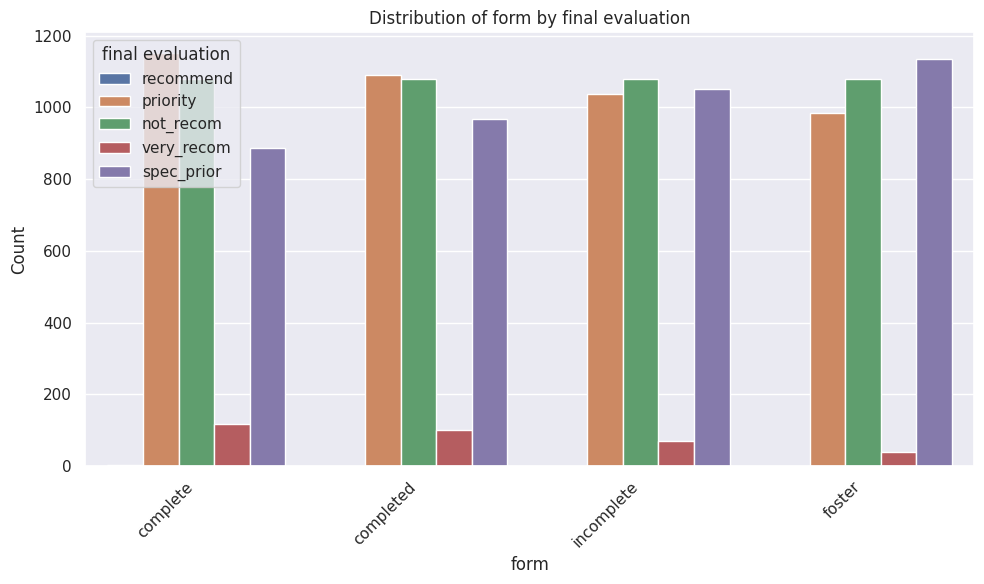

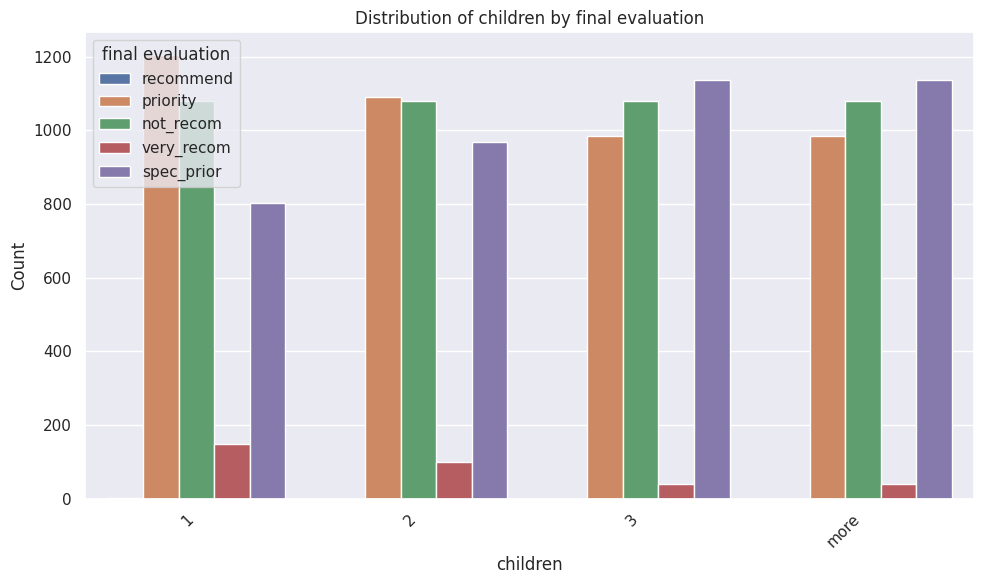

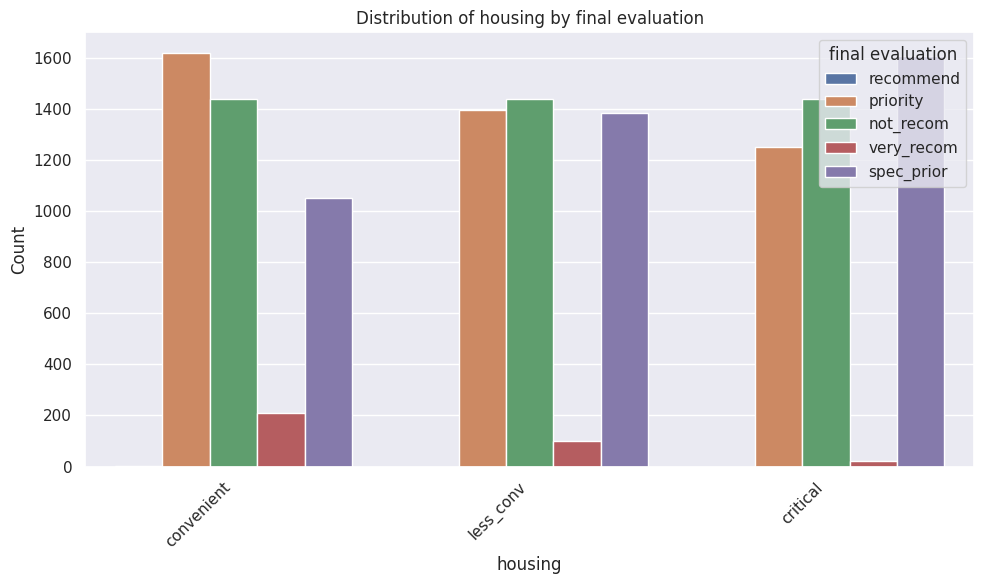

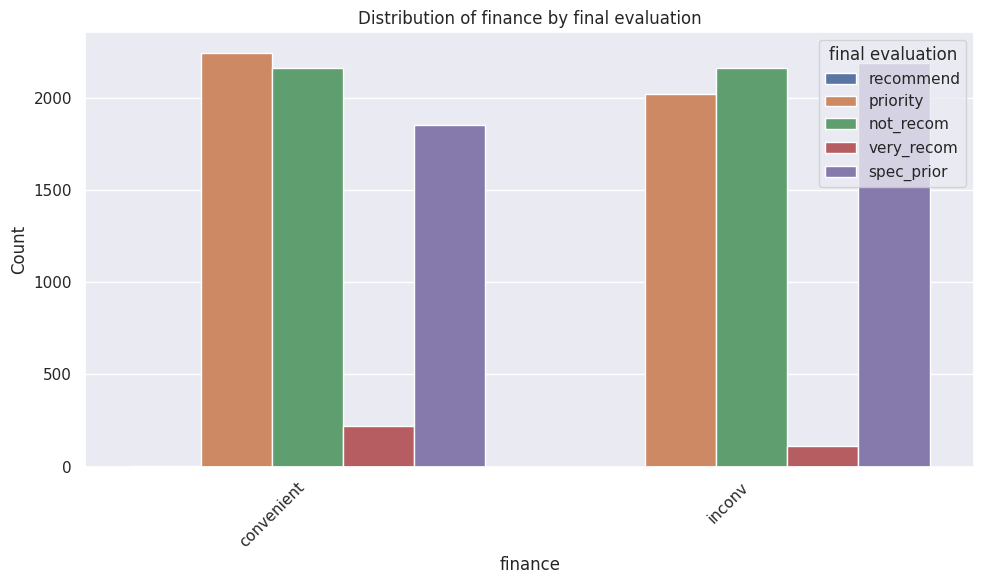

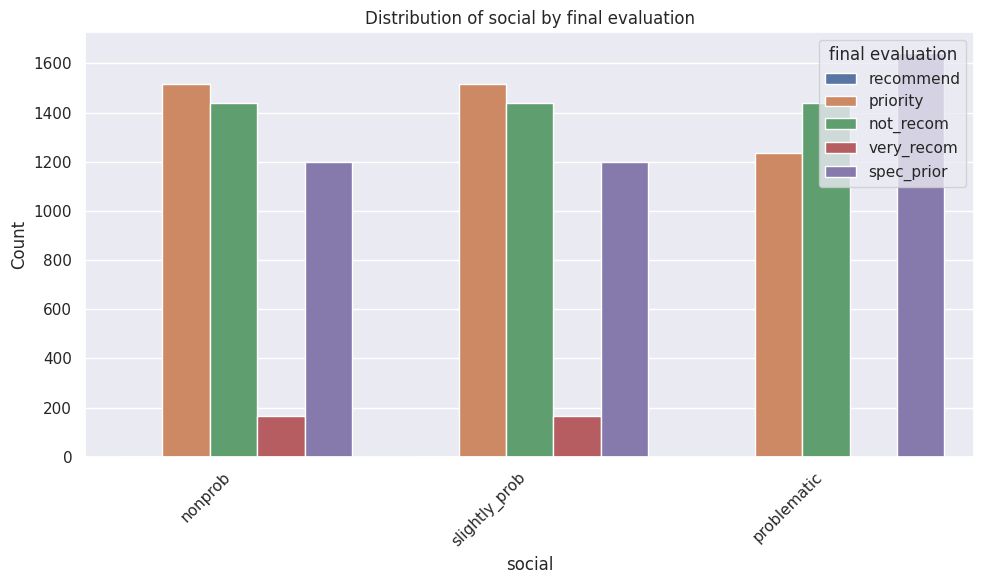

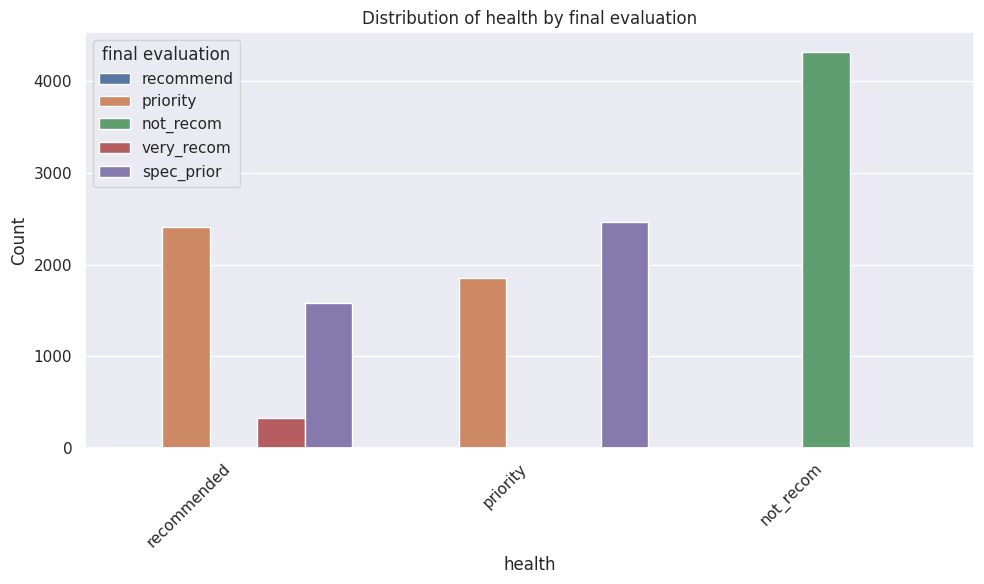

In [16]:
# Categorical-Categorical relationships
categorical_cols = df.select_dtypes(include='object').columns.tolist()
target_col = 'final evaluation' # Assuming 'final evaluation' is the target variable

# Iterate through categorical columns and create countplots with the target variable
for col in categorical_cols:
    if col != target_col:
        plt.figure(figsize=(10, 6))
        sns.countplot(data=df, x=col, hue=target_col)
        plt.title(f'Distribution of {col} by {target_col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

# Multivariate Analysis

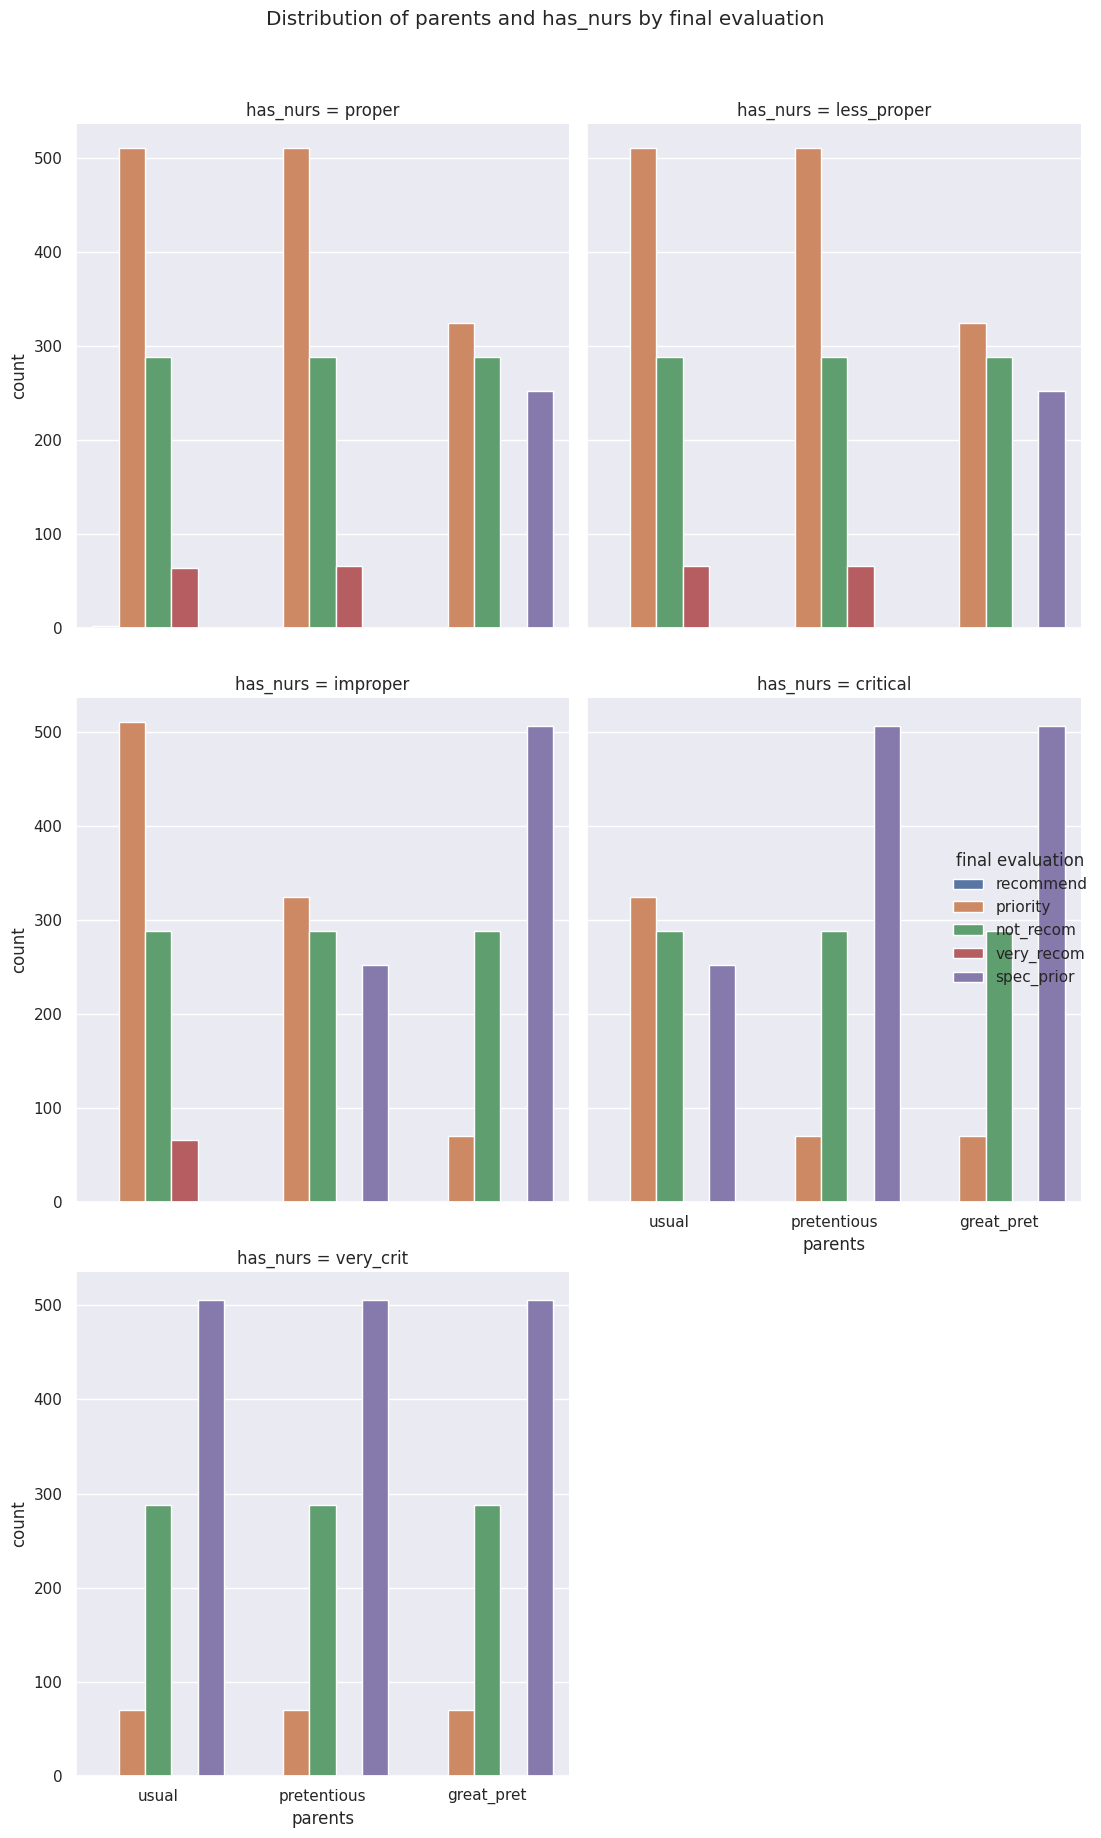

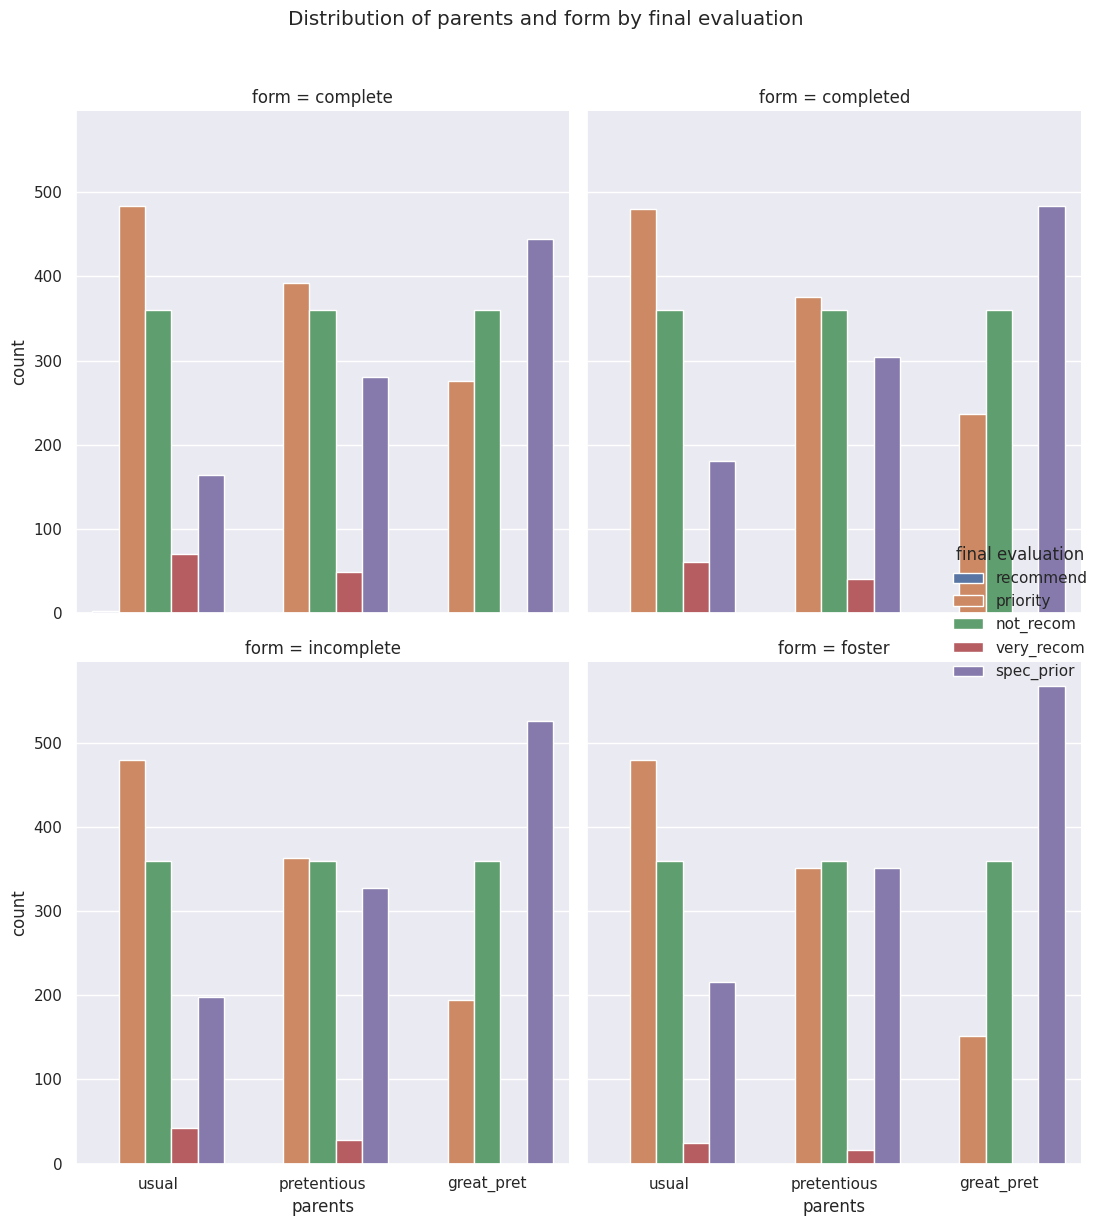

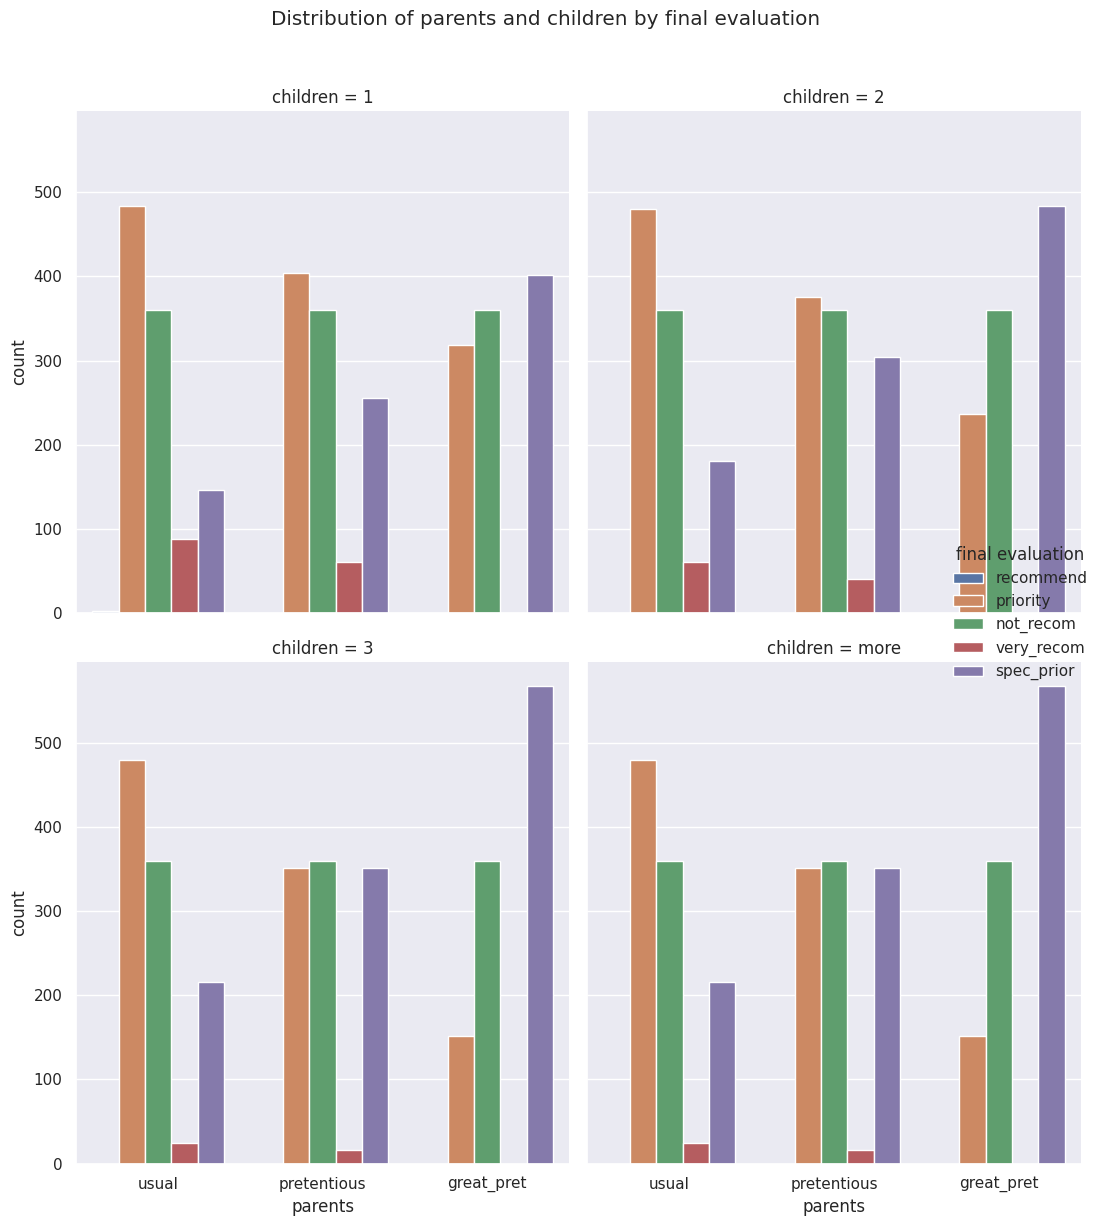

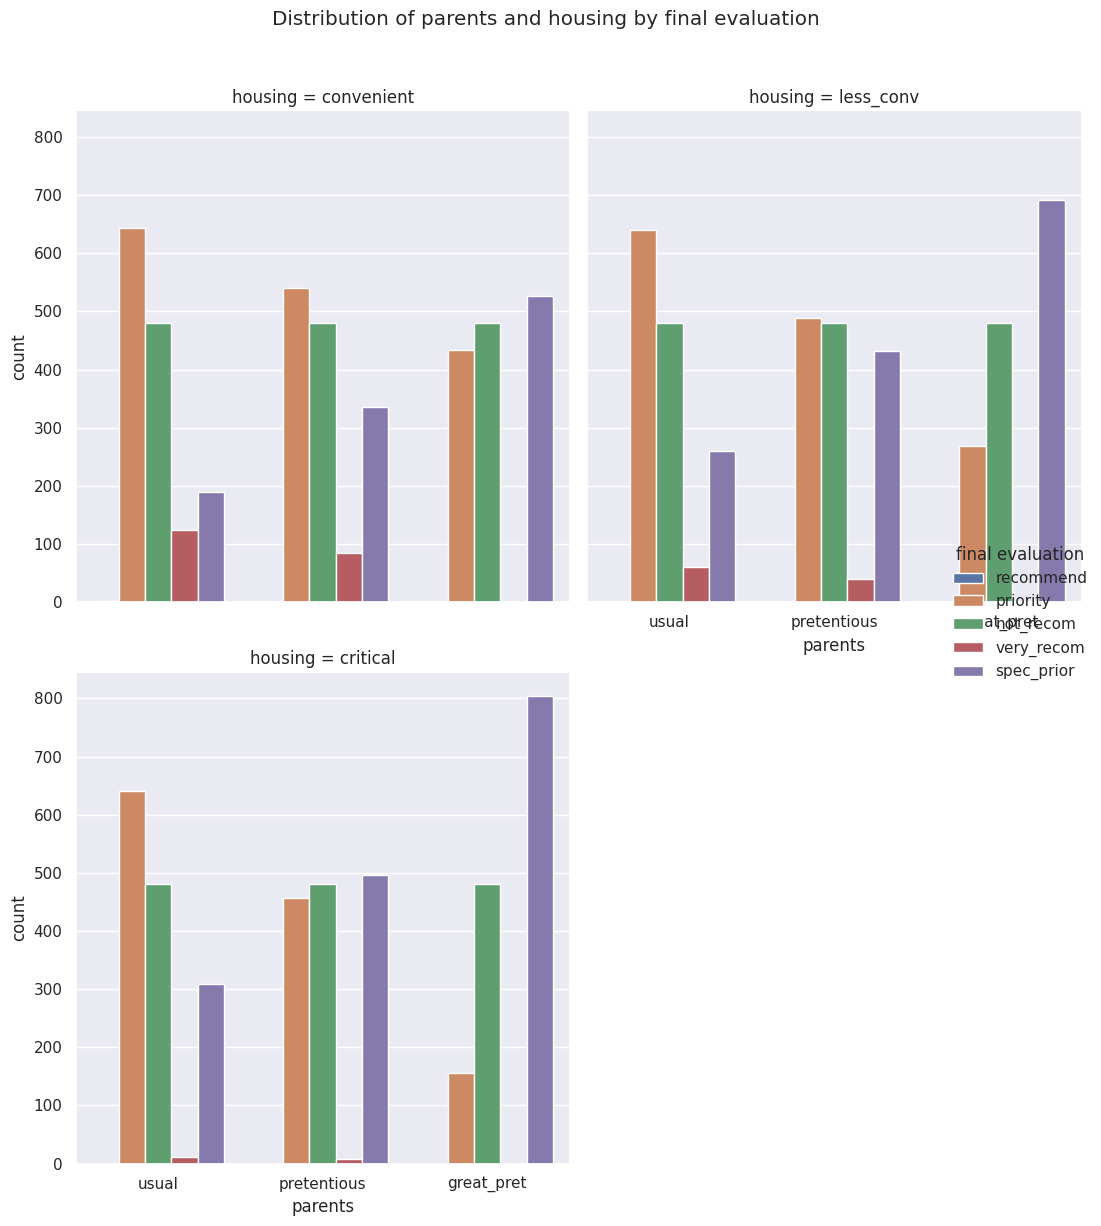

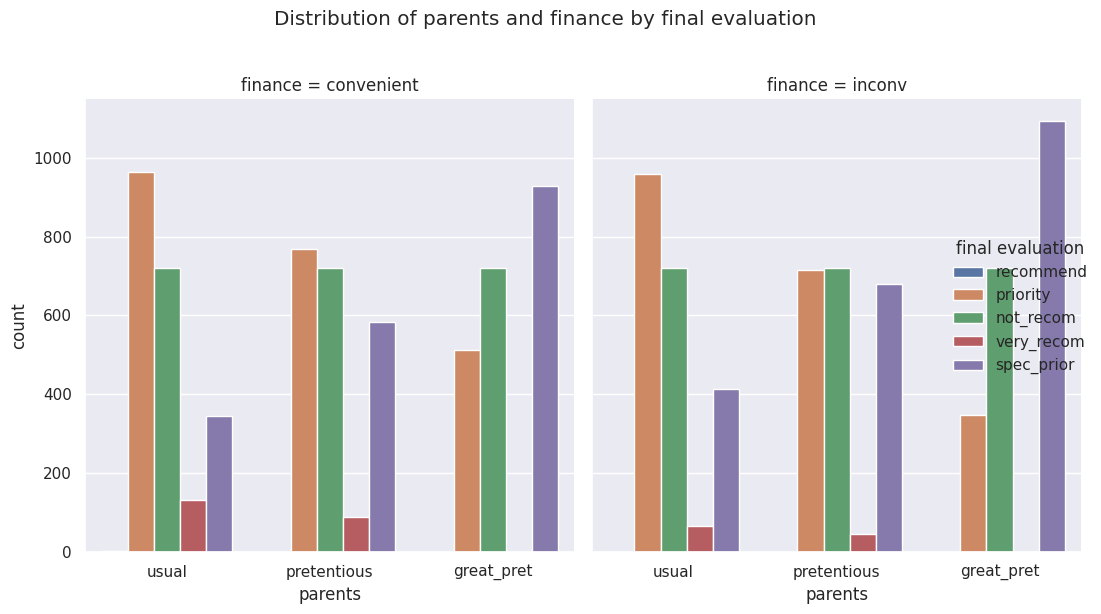

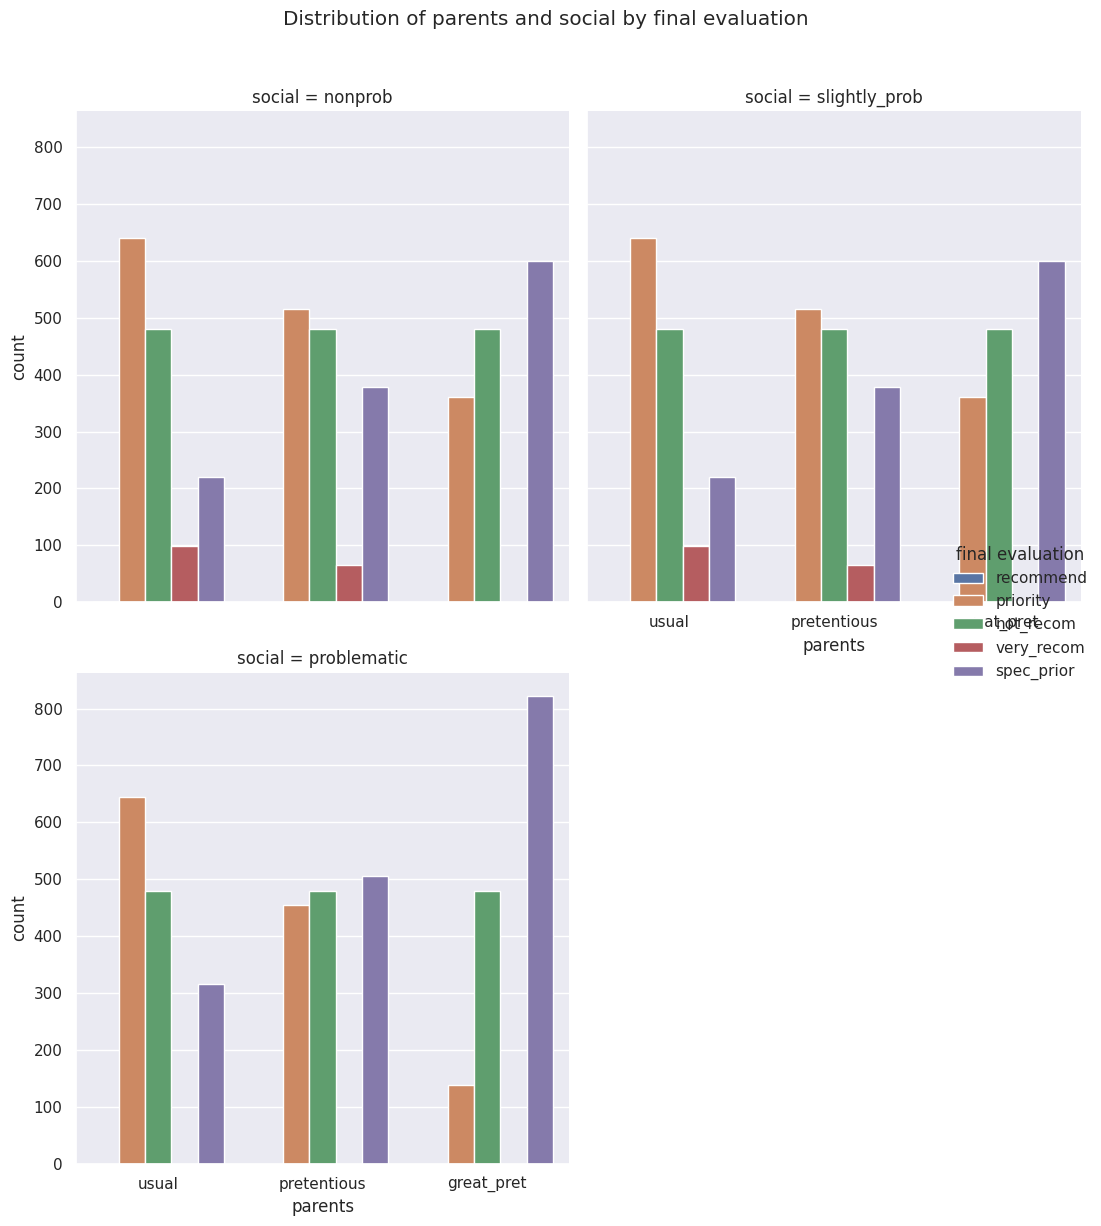

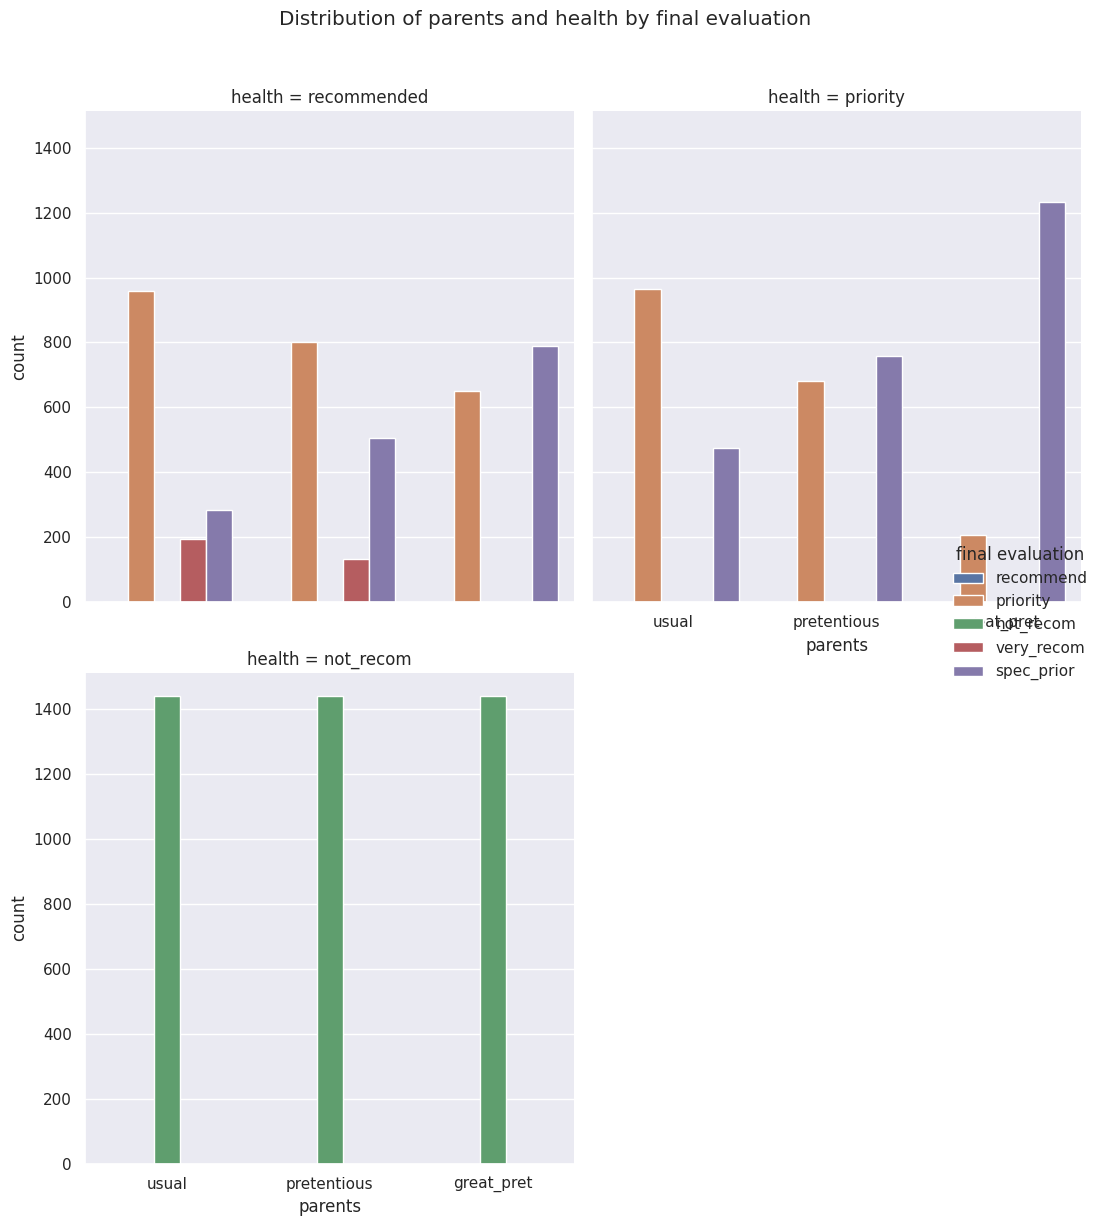

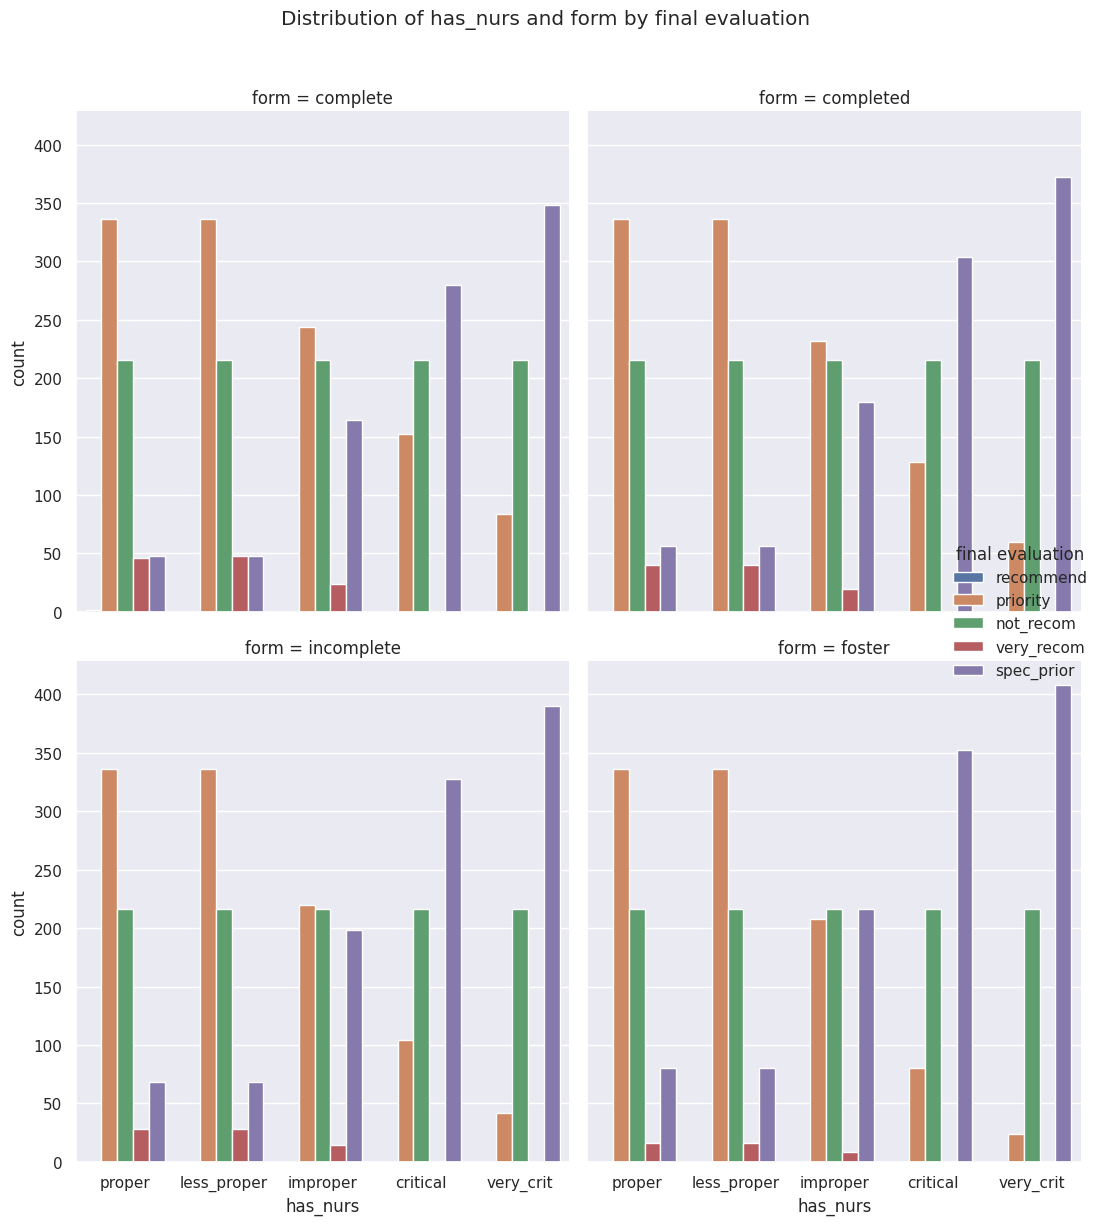

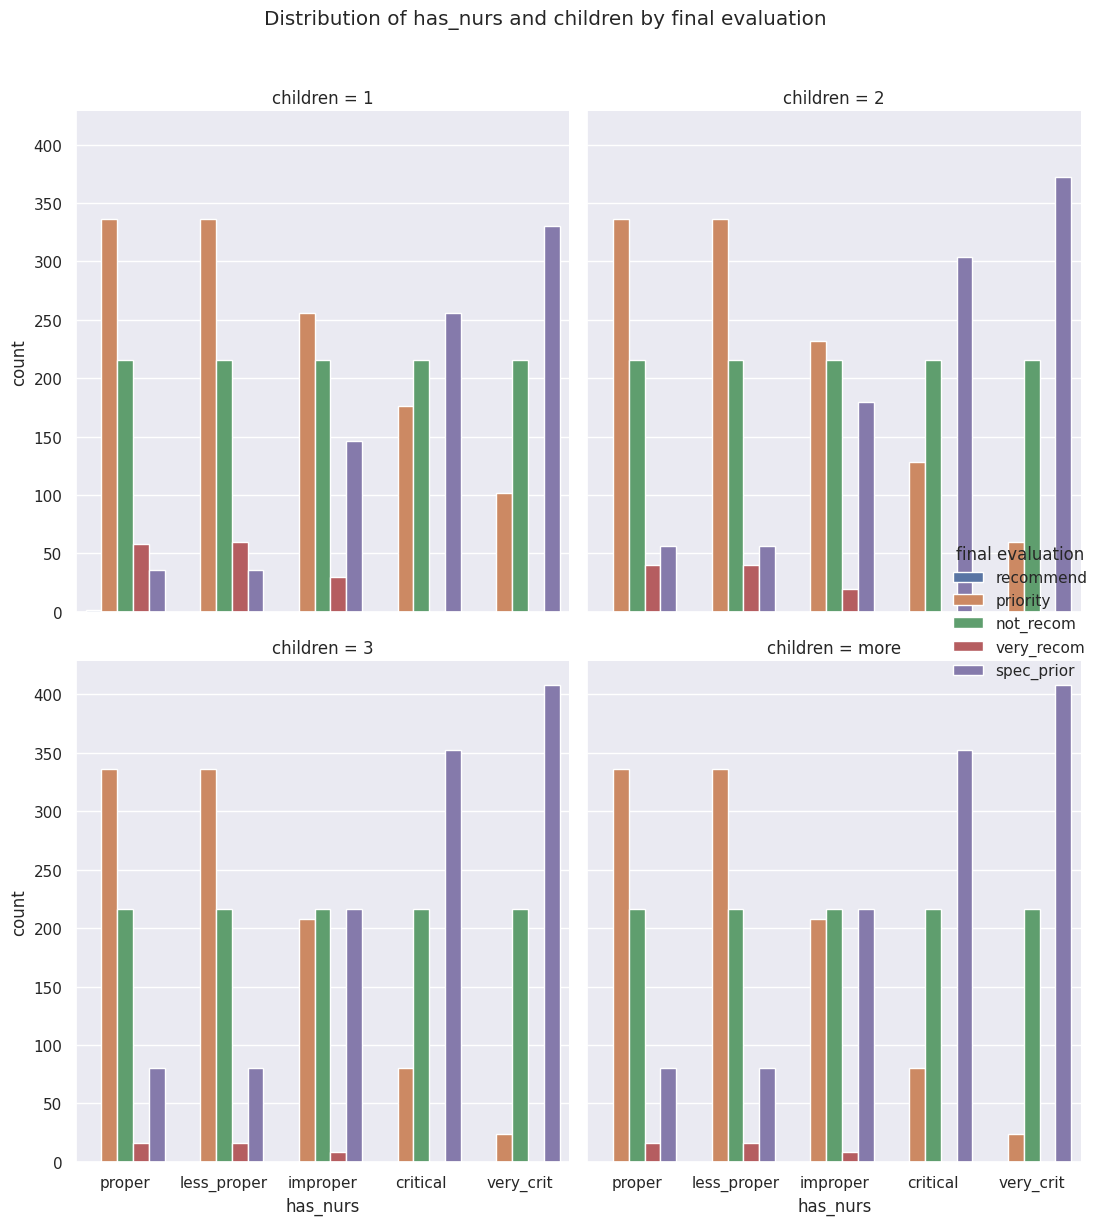

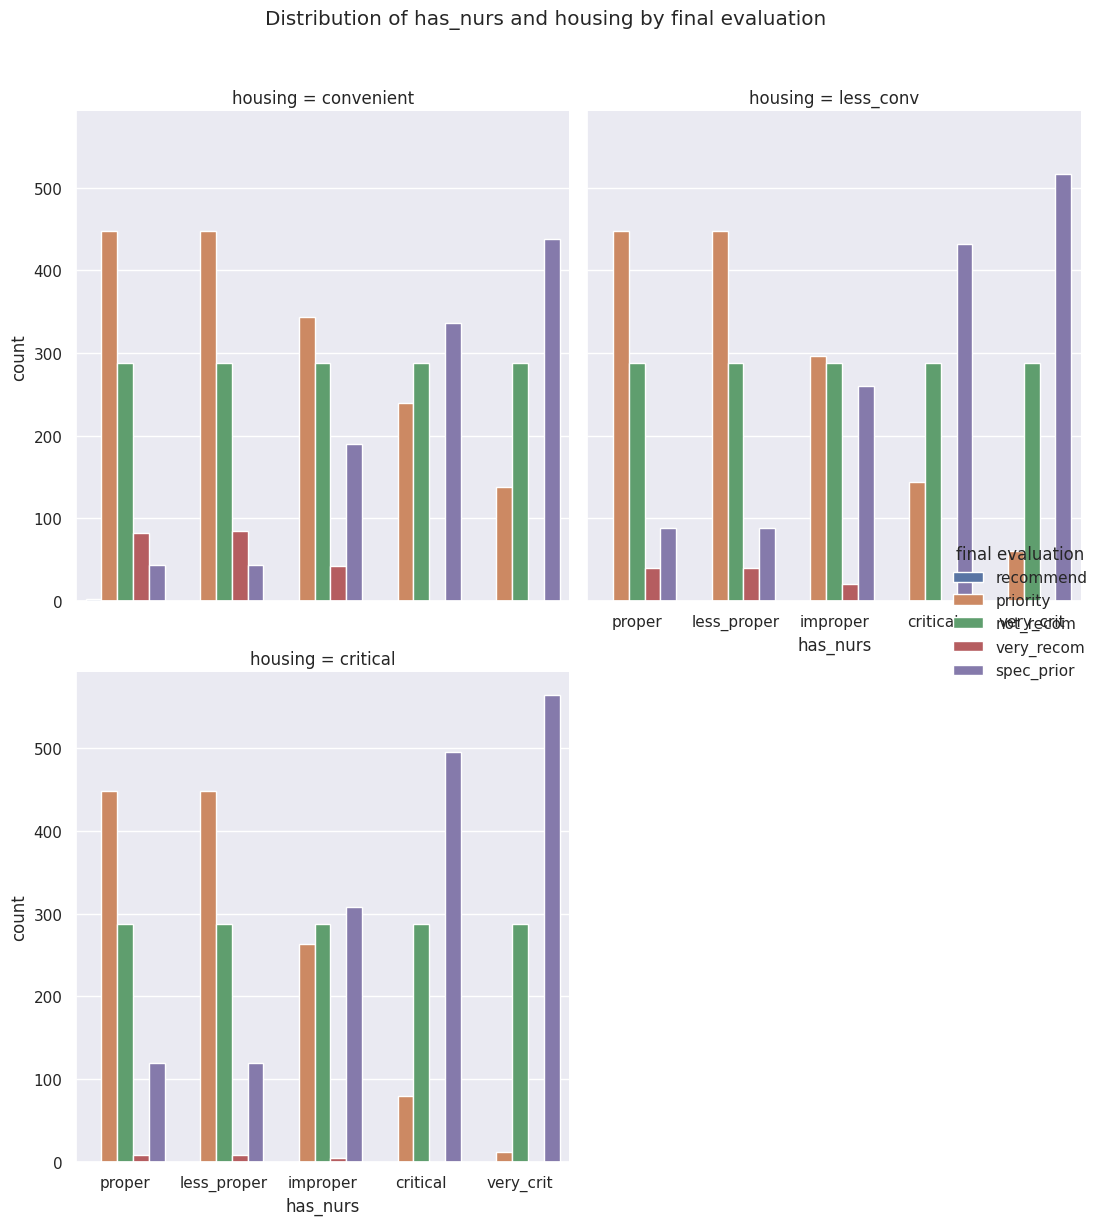

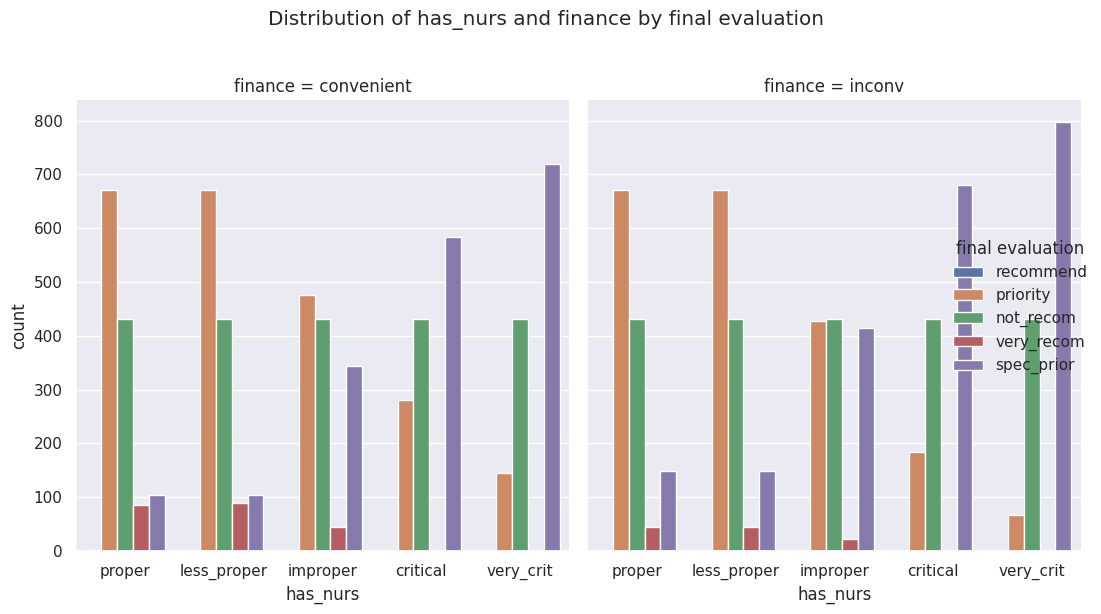

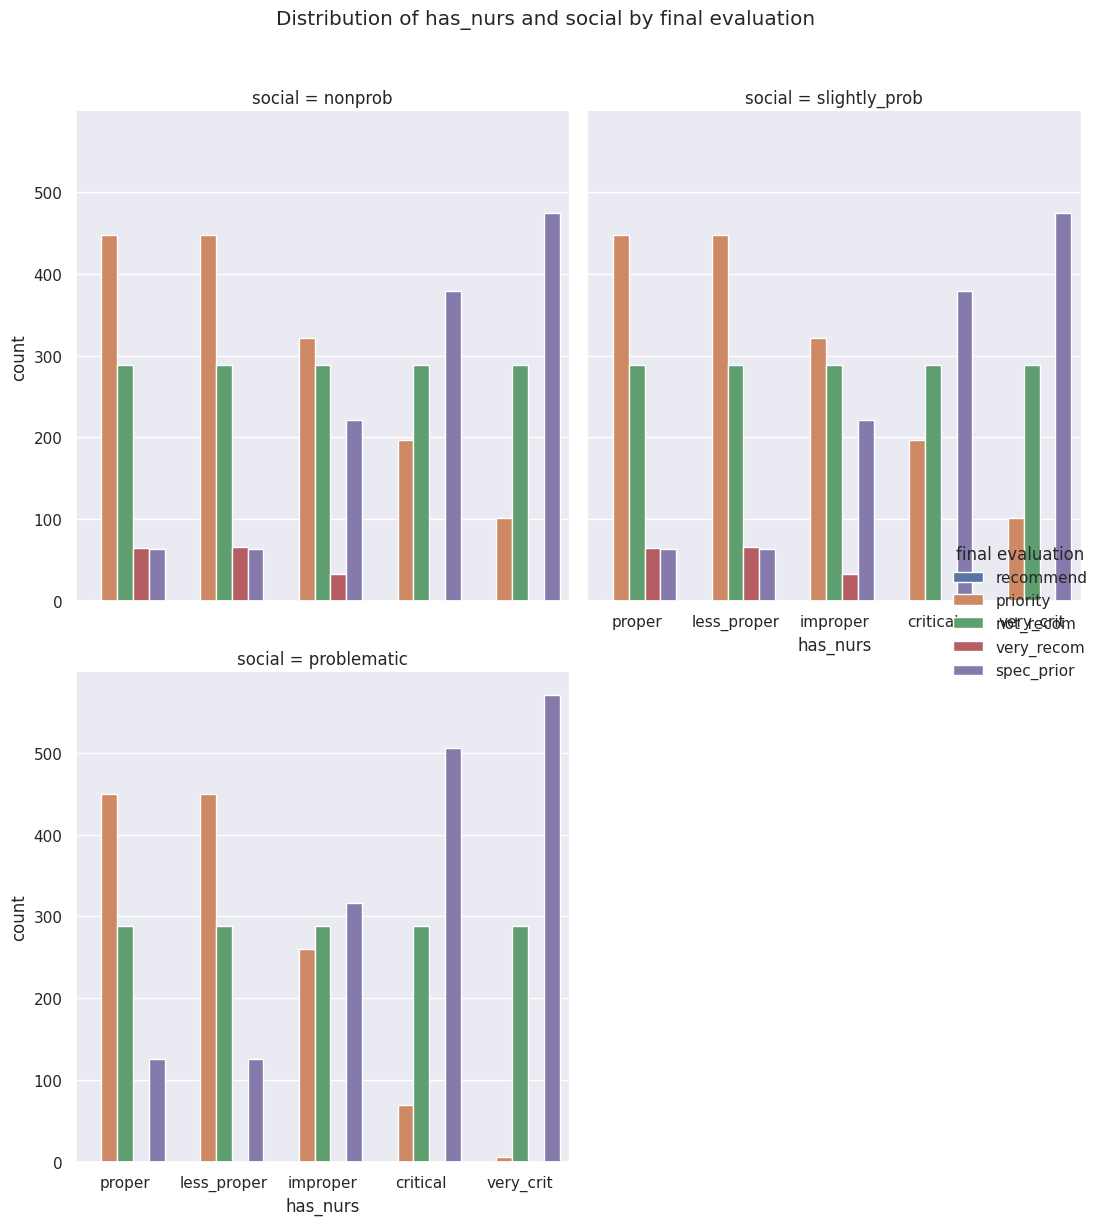

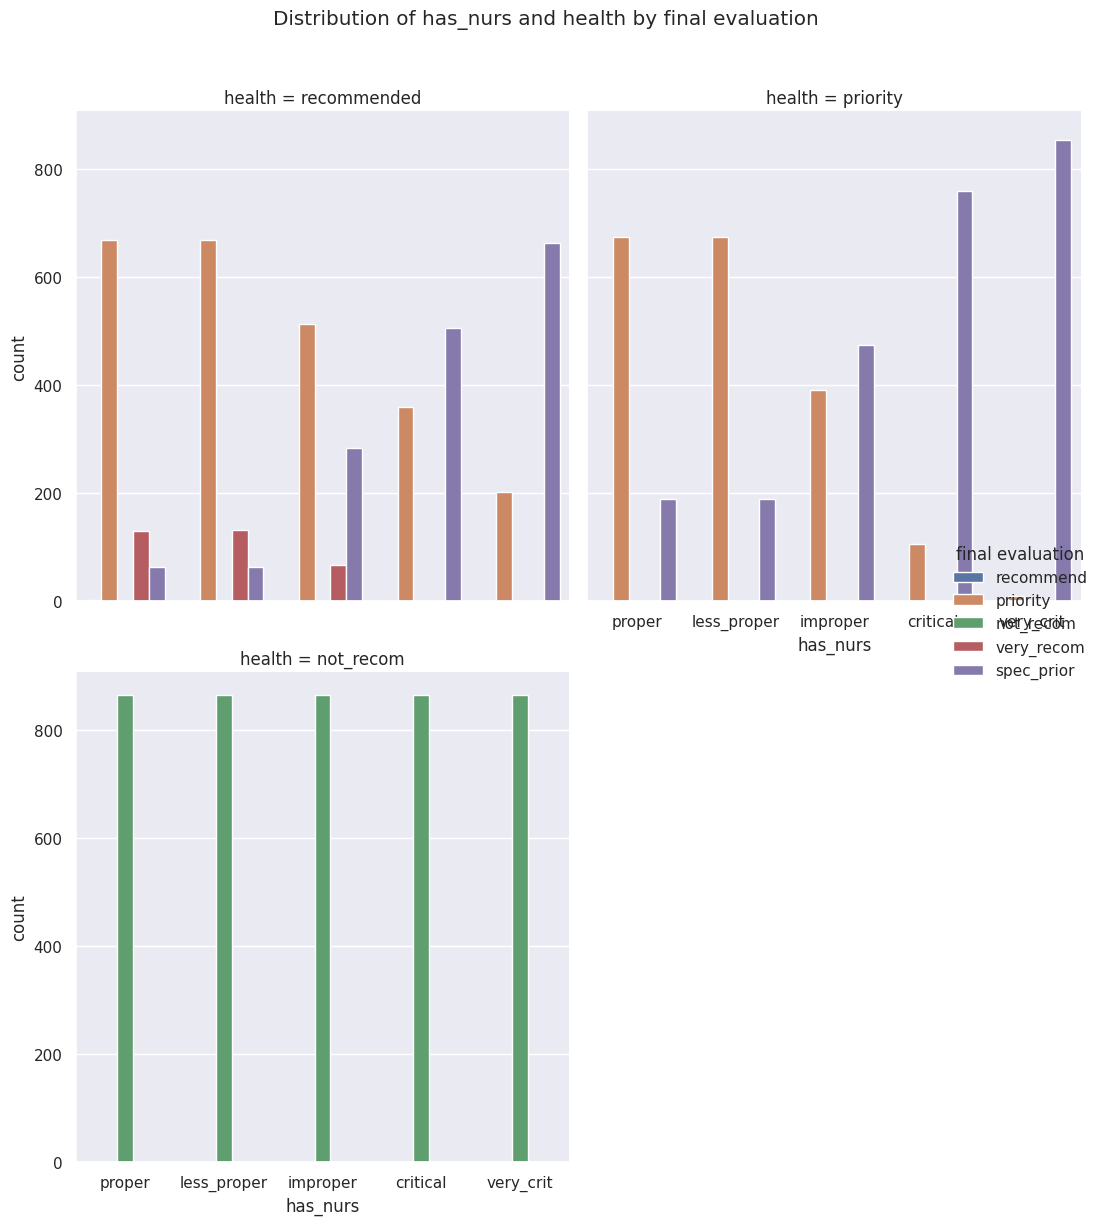

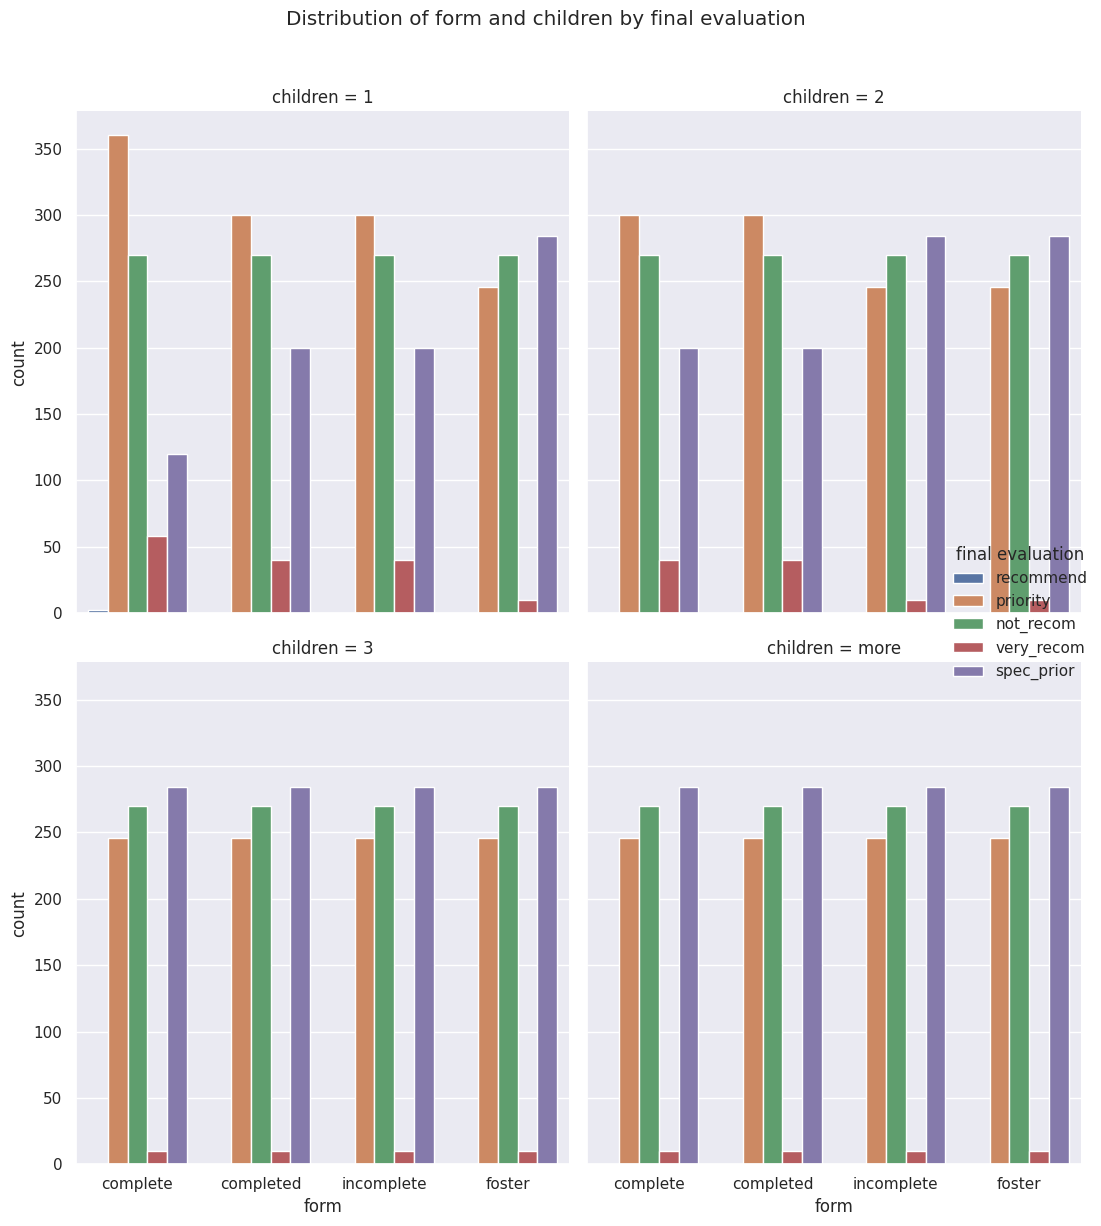

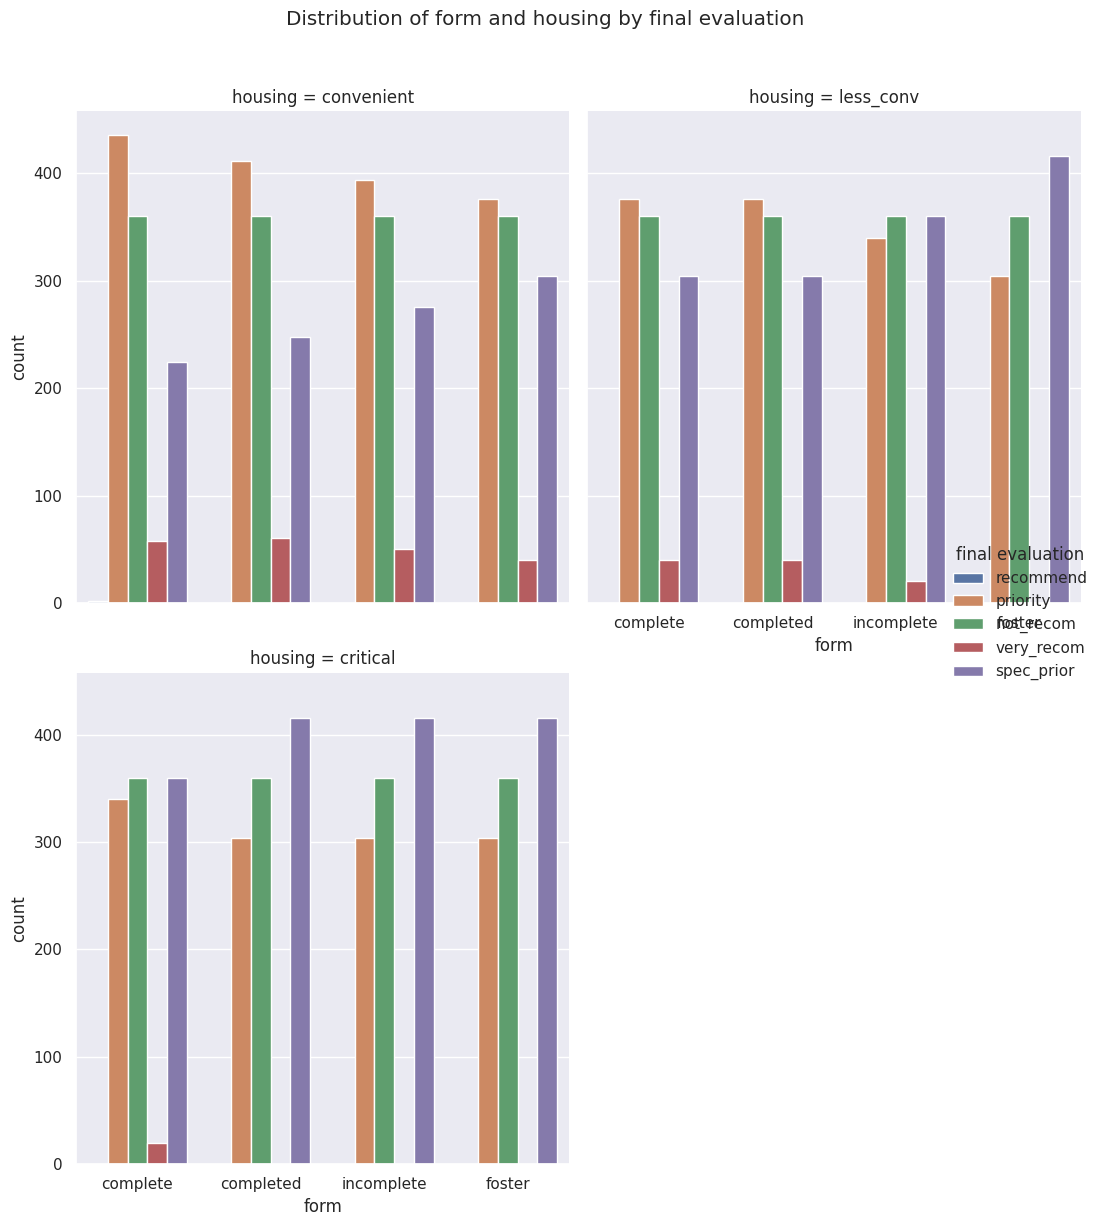

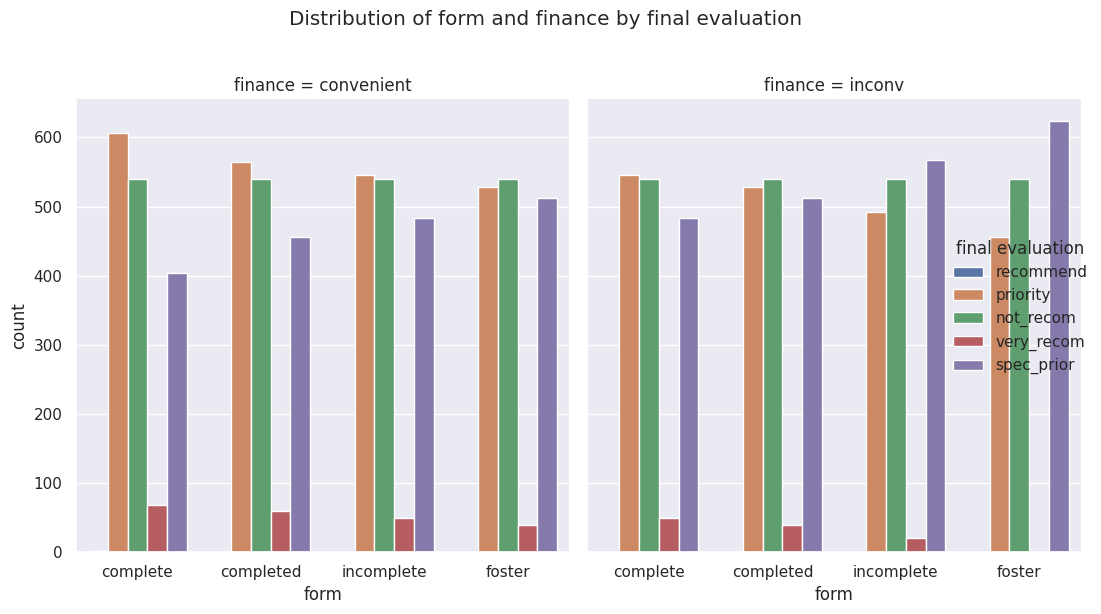

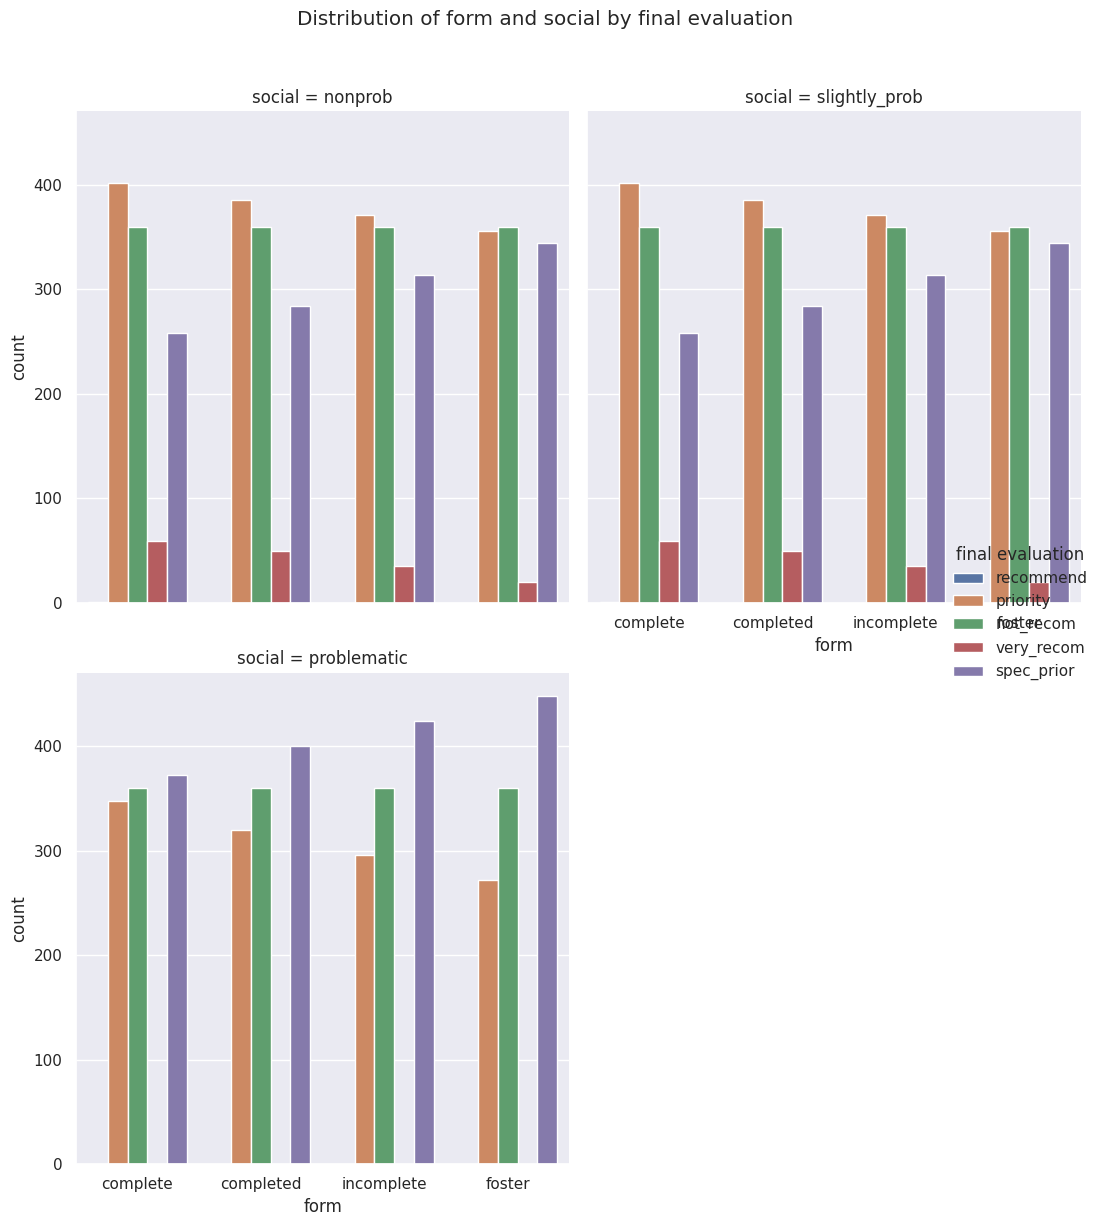

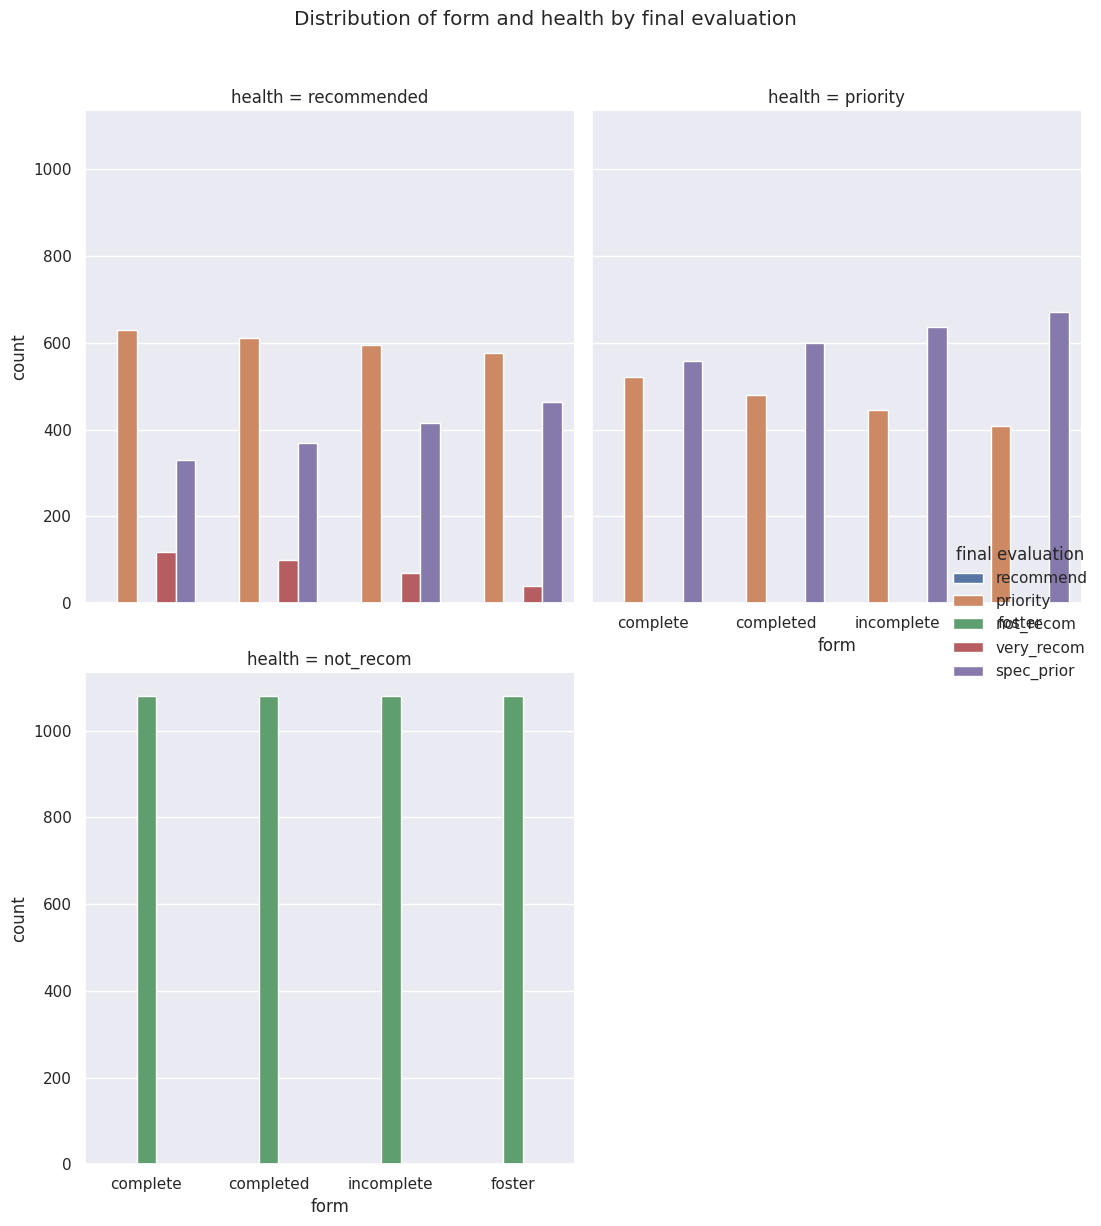

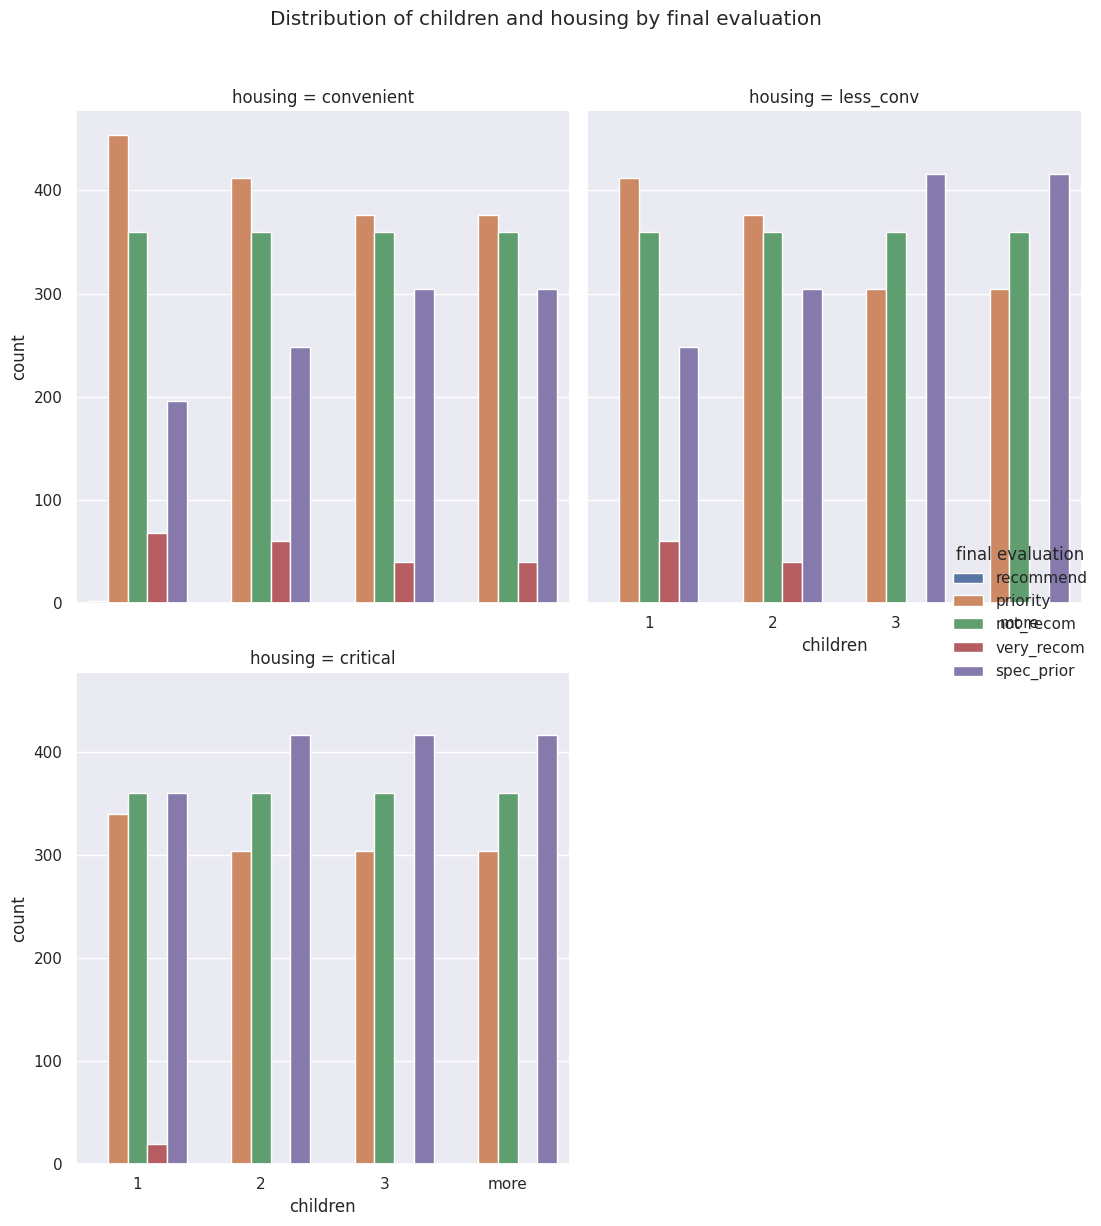

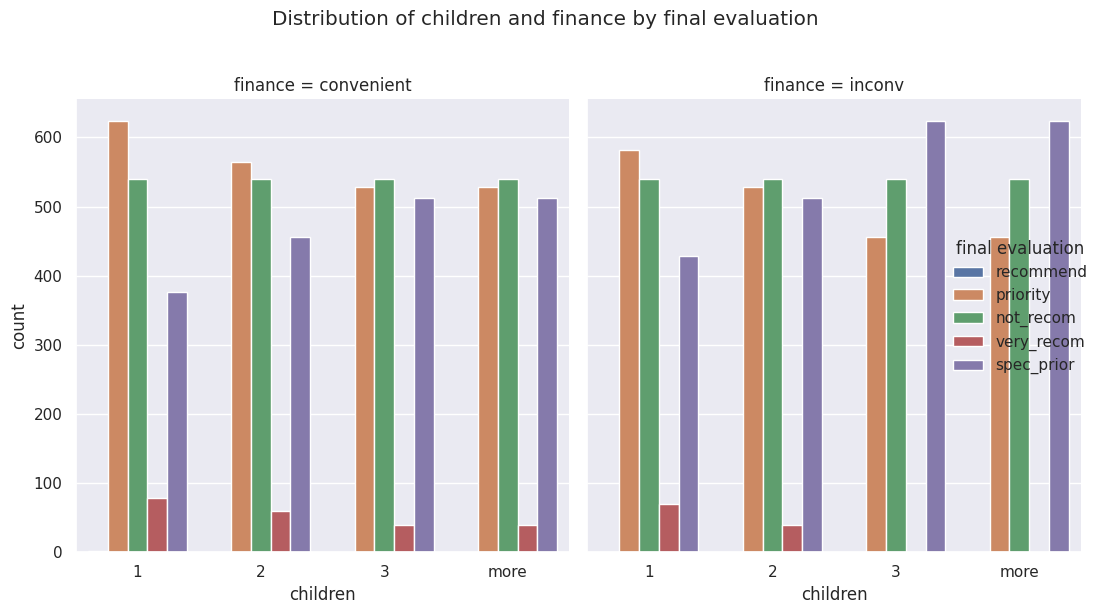

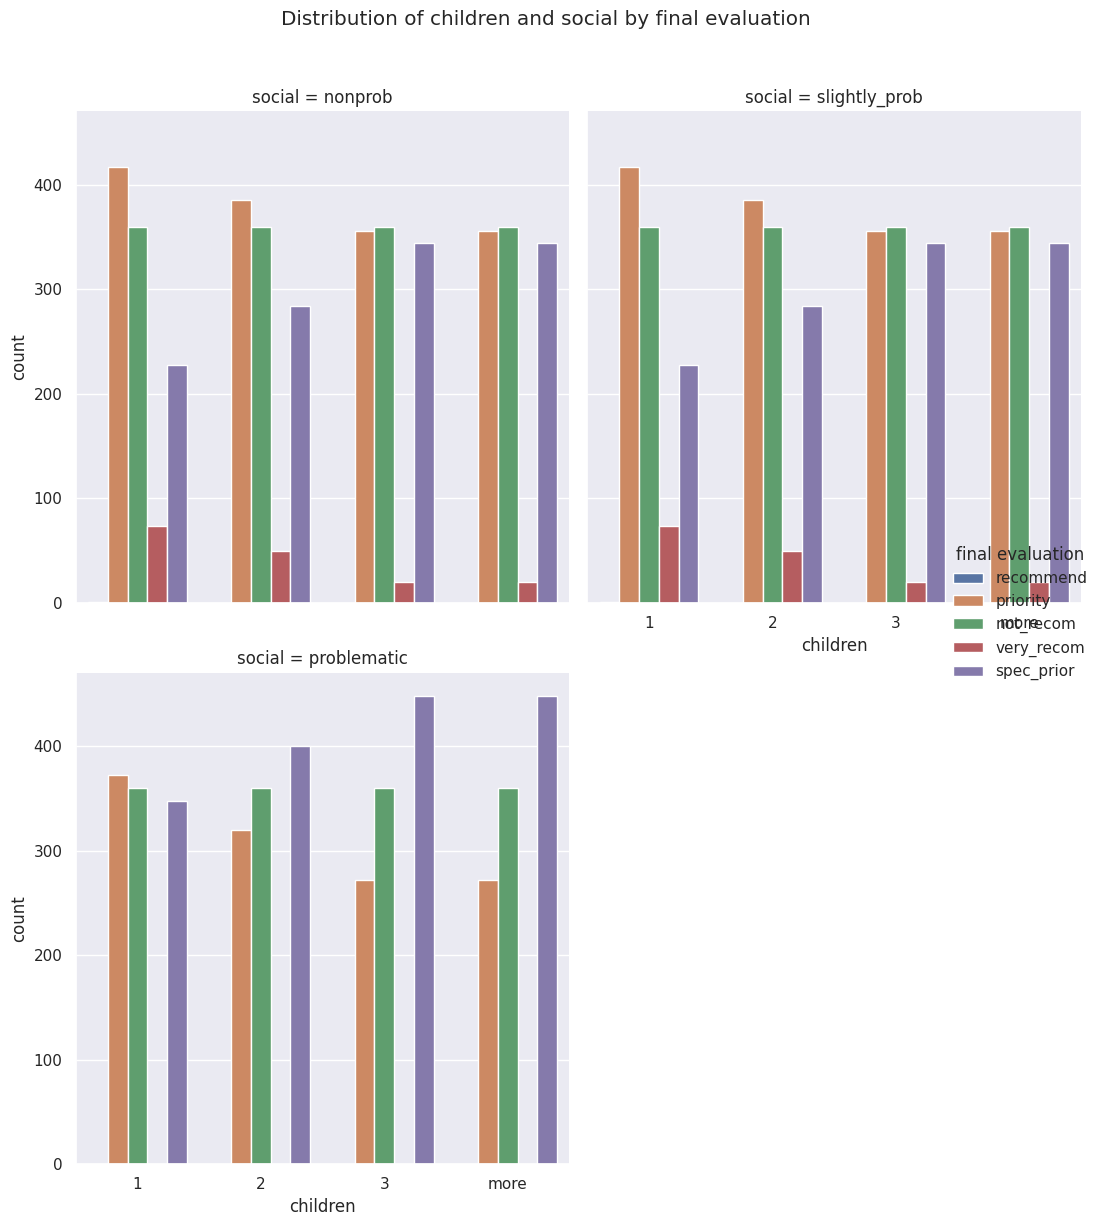

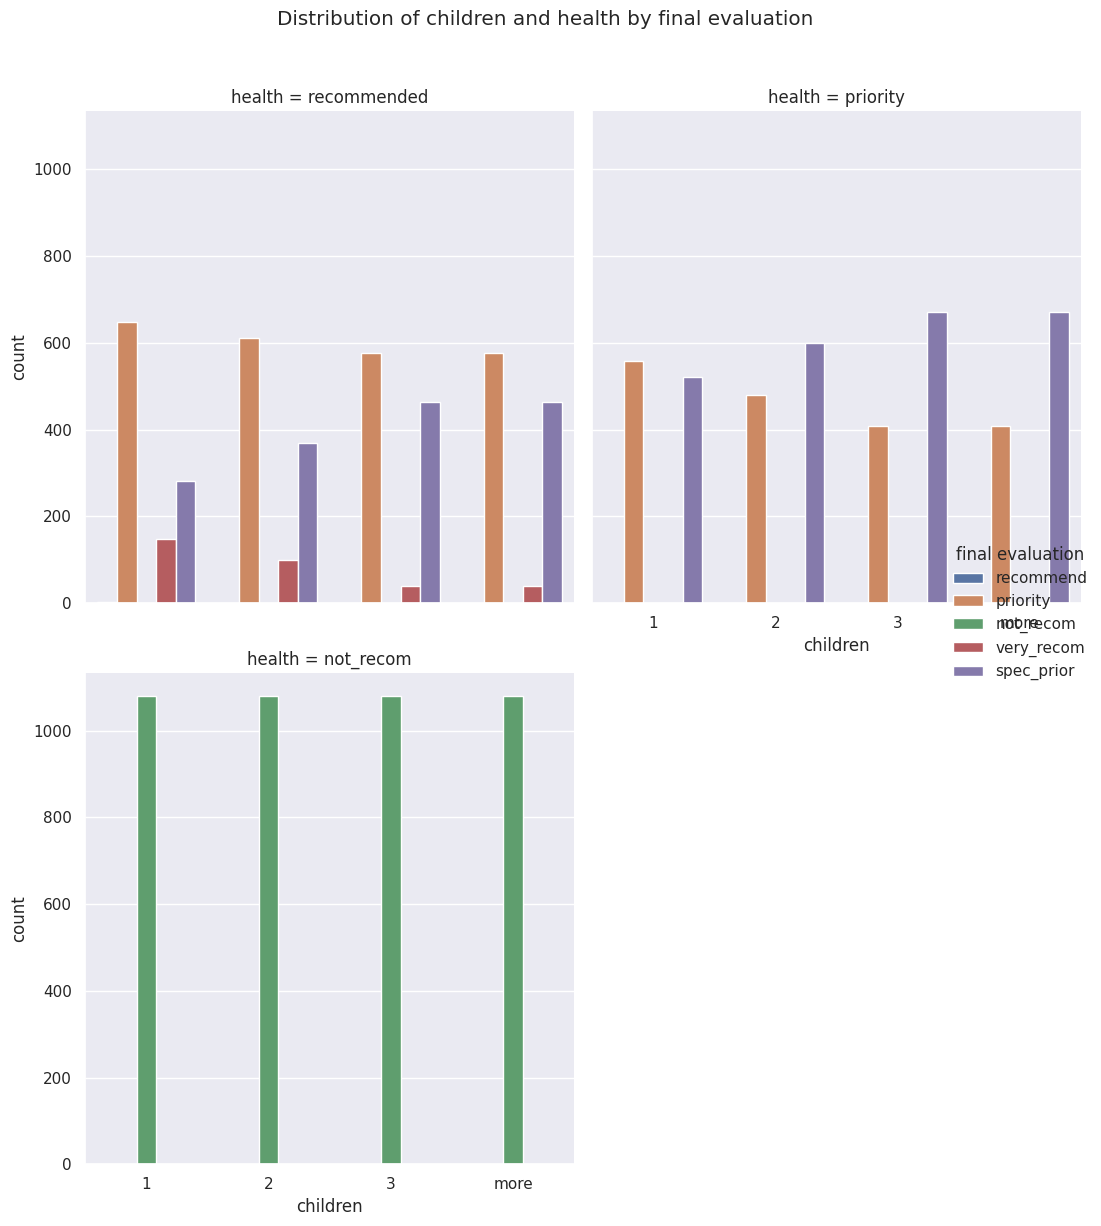

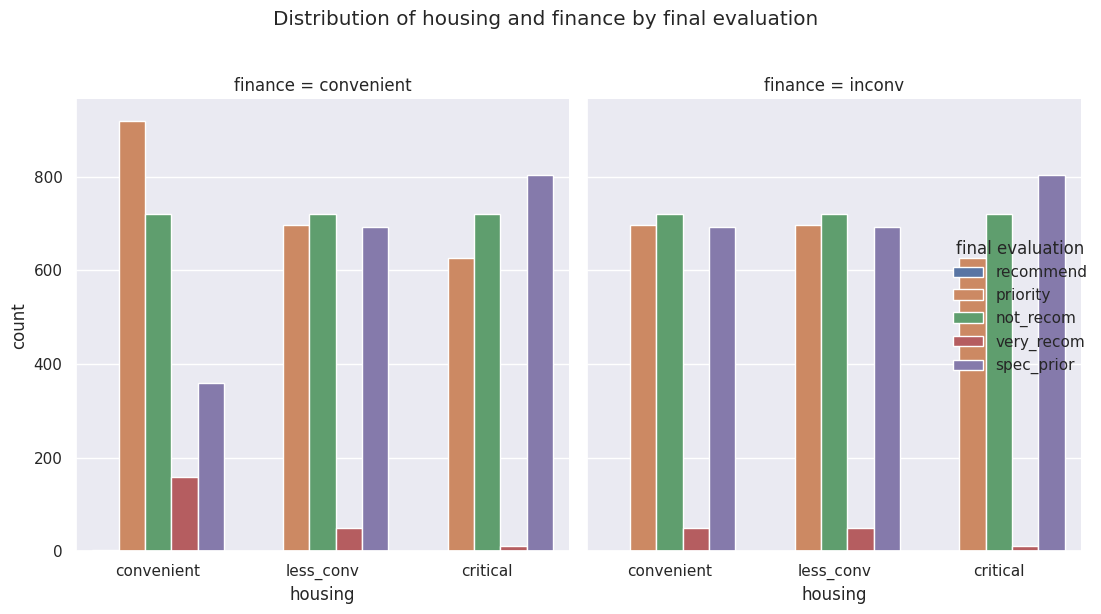

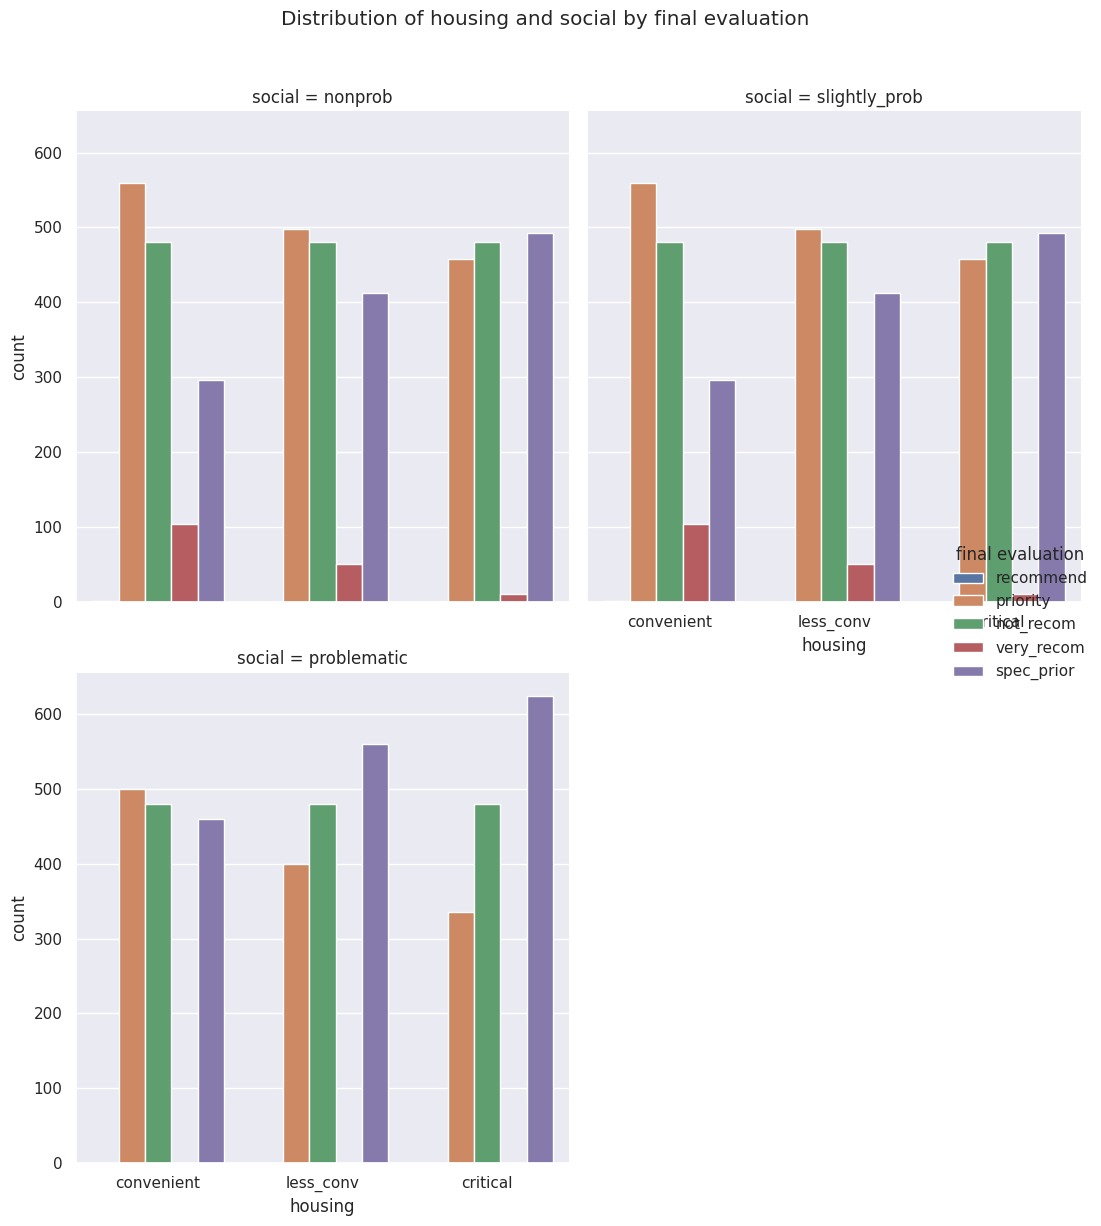

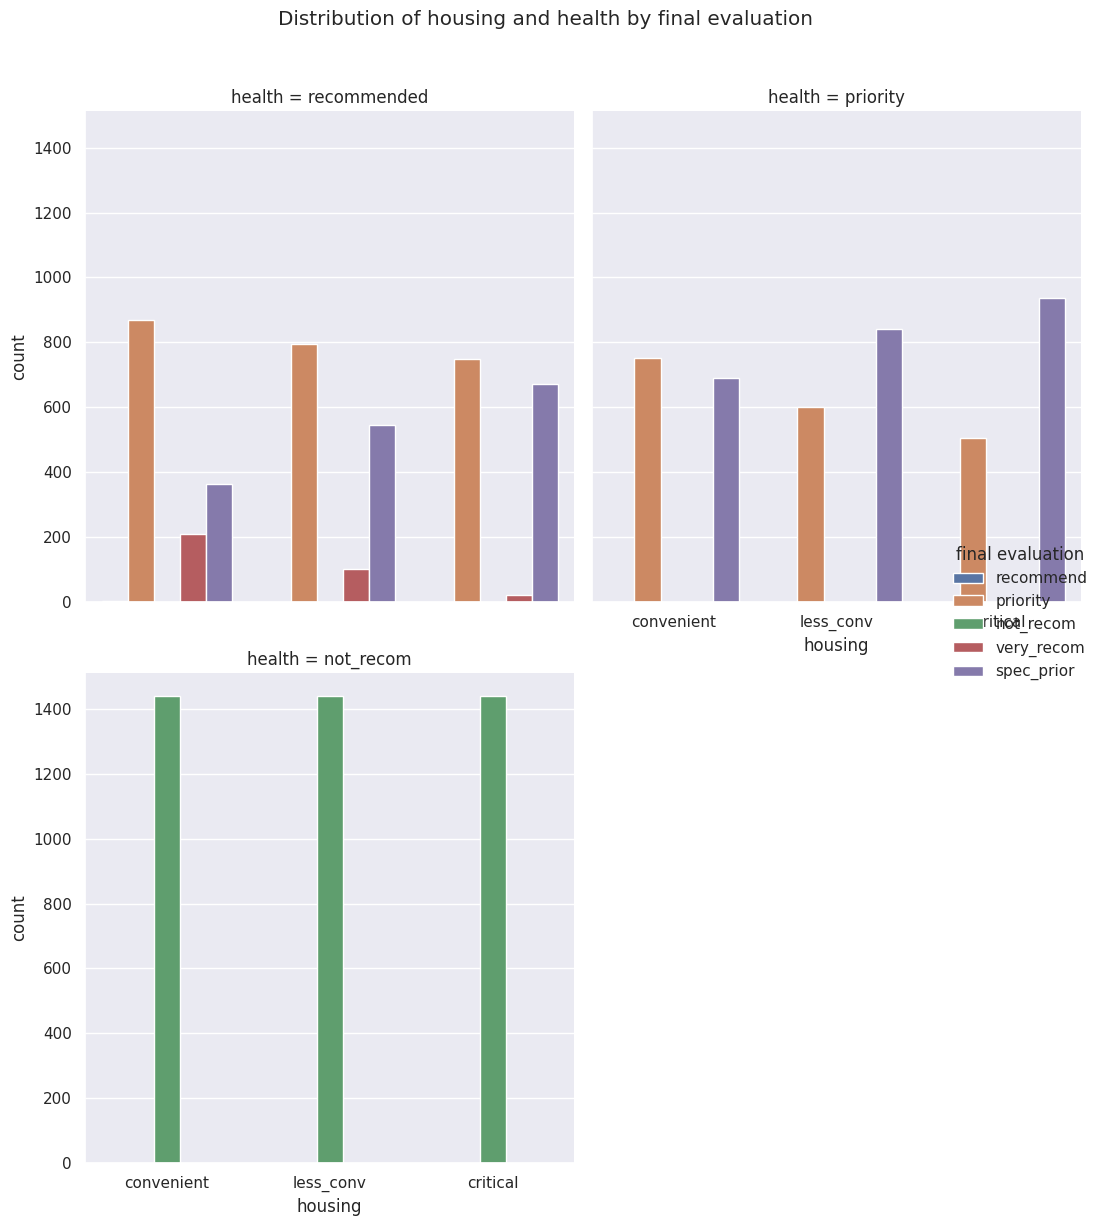

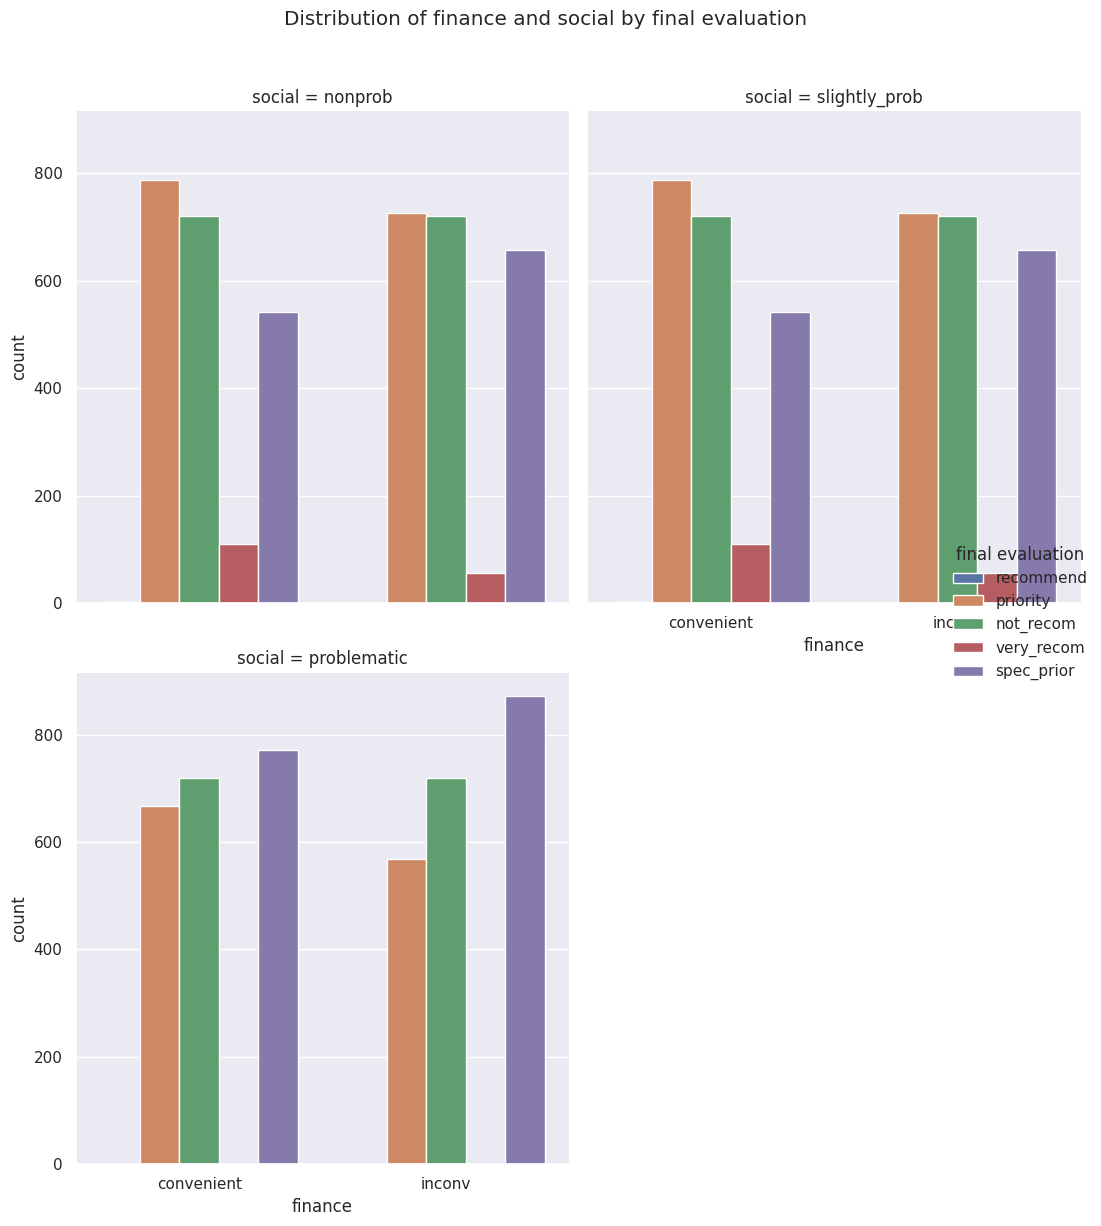

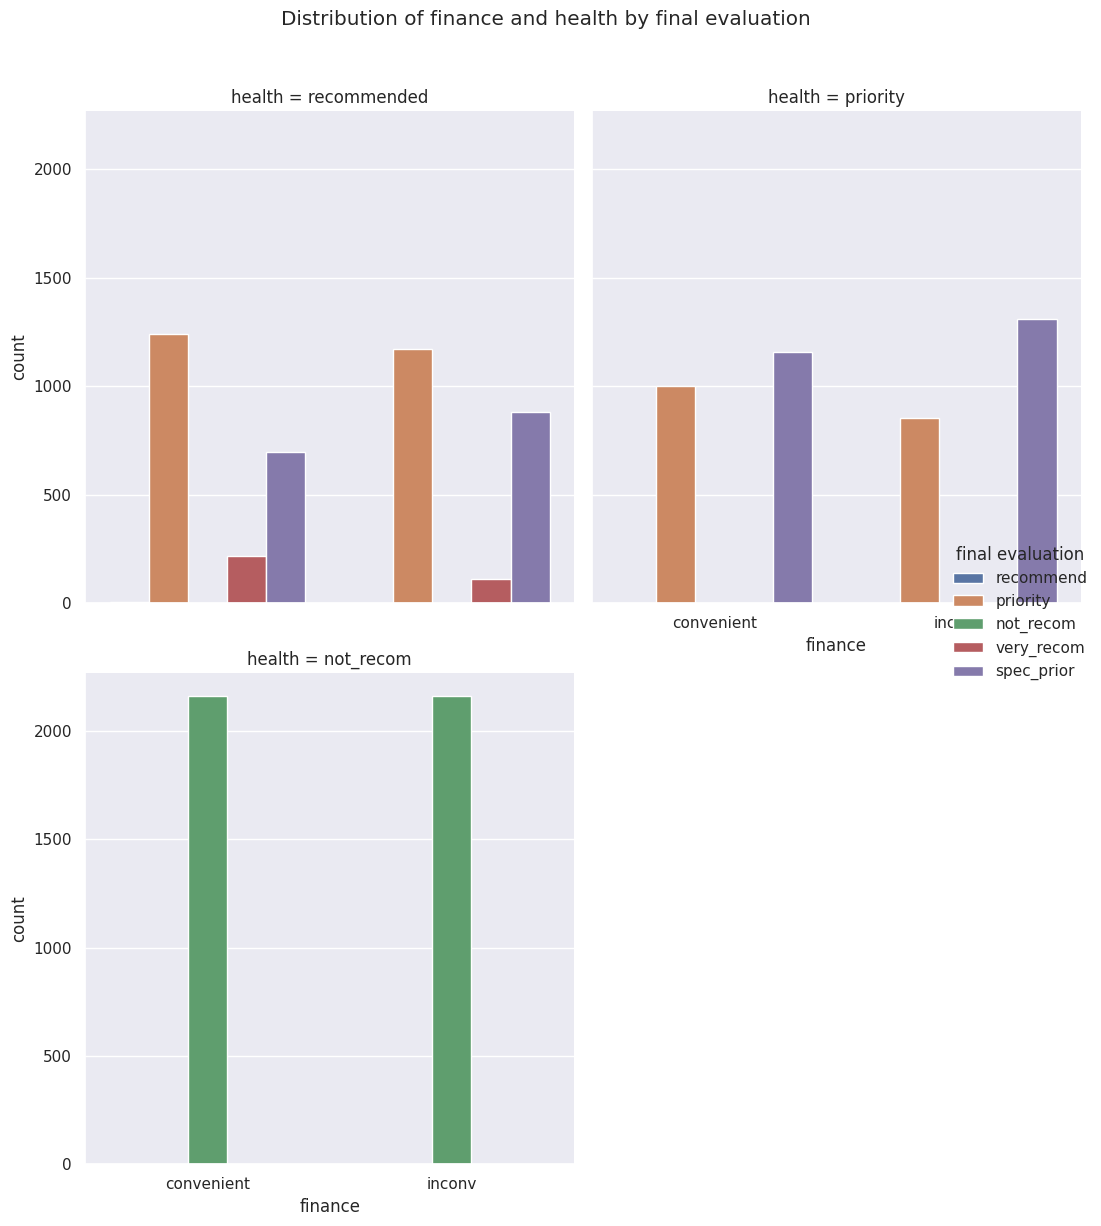

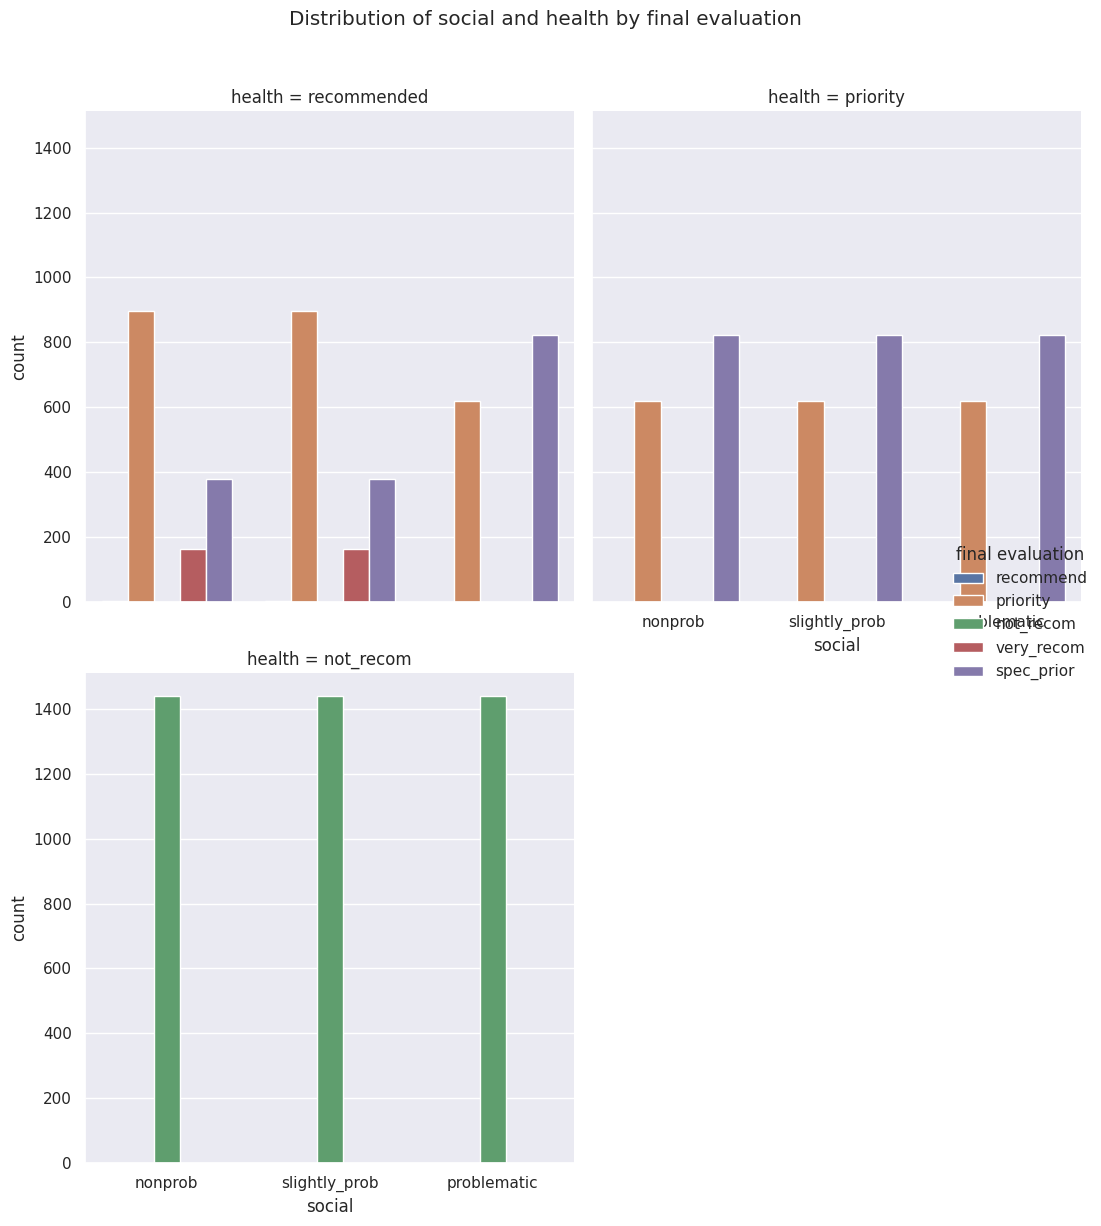

In [18]:
# Multivariate Analysis (Categorical-Categorical-Categorical relationships)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
target_col = 'final evaluation'

# Iterate through combinations of three categorical columns and create countplots
from itertools import combinations

for col1, col2 in combinations(categorical_cols, 2):
    if col1 != target_col and col2 != target_col:
        # Use sns.catplot instead of sns.countplot to use the 'col' parameter
        sns.catplot(data=df, x=col1, hue=target_col, col=col2, kind='count', col_wrap=2, height=6, aspect=0.8)
        plt.suptitle(f'Distribution of {col1} and {col2} by {target_col}', y=1.02) # Add a suptitle
        plt.tight_layout()
        plt.show()

# Thank you